In [1]:
import pickle
import os
import copy
import matplotlib.pyplot as plt
import numpy as np
import paper_style  # apply the style automatically
import gc
import psutil
import yaml
import sys
import torch
import io
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




# Input Config

In [2]:
df = pd.read_csv('/home/evrond/rl_for_curobo_analysis/projects_root/experiments/armsResults_date1409_rows960_rowTypeTrial.csv')
df

,sim_id,alg,task_type,task_level,task_seed,col_chance,task_val
0,2025-09-08_03:30:27_R_ur5e_N4_AO_Tbin_s5_l2,"O(400, 1)",bin,2,5,0.000,6.000000
1,2025-09-08_04:01:24_R_ur5e_N4_AO_Tbin_s3_l4,"O(400, 1)",bin,4,3,0.022,7.000000
2,2025-09-08_03:27:28_R_ur5e_N4_AO_Tbin_s4_l2,"O(400, 1)",bin,2,4,0.000,6.000000
3,2025-09-08_04:23:09_R_ur5e_N4_AO_Tbin_s4_l5,"O(400, 1)",bin,5,4,0.000,8.000000
4,2025-09-08_04:04:41_R_ur5e_N4_AO_Tbin_s4_l4,"O(400, 1)",bin,4,4,0.000,6.000000
...,...,...,...,...,...,...,...
955,2025-09-08_22:54:49_R_ur5e_N4_ACC_Tfollow_s5_l2,CC(500),follow,2,5,0.000,0.304553
956,2025-09-08_22:41:53_R_ur5e_N4_ACC_Tfollow_s2_l2,CC(500),follow,2,2,0.000,0.297082
957,2025-09-08_22:22:11_R_ur5e_N4_ACC_Tfollow_s3_l1,CC(500),follow,1,3,0.000,0.310030
958,2025-09-08_23:40:16_R_ur5e_N4_ACC_Tfollow_s3_l4,CC(500),follow,4,3,0.278,0.307996


In [3]:
def normalize(df, baseline_alg='O(400, 5)', normalization_type='diff_from_baseline',add_baseline_raw_vals=True):
    """
    normalization_type: "diff_from_baseline" or "ratio_from_max"
        diff_from_baseline: normalized_task_val = task_val - baseline_alg's task_val at the same (task_type, task_seed, task_level)
        ratio_from_max: normalized_task_val = task_val / max task_val over all algs at the same(task_type, task_seed, task_level)
    
    """
    
    df_work = df.copy()
    df_work['normalized_task_val'] = 0.0
    df_work['normalized_col_chance'] = 0.0
    if add_baseline_raw_vals:
        df_work['baseline_task_val'] = 0.0
        df_work['baseline_col_chance'] = 0.0
    
    # Get all unique combinations of task_type, task_seed, task_level
    unique_combinations = df_work[['task_type', 'task_seed', 'task_level']].drop_duplicates() # df with all unique combinations of task_type, task_seed, task_level, each appears only once
    
    for idx, row in unique_combinations.iterrows():
        # print(idx, row)
        task_type = row['task_type']
        task_seed = row['task_seed'] 
        task_level = row['task_level']
        
        # Find the baseline_alg rows with matching task_type, task_seed, task_level
        baseline_alg_mask = (
            (df_work['alg'] == baseline_alg) & 
            (df_work['task_type'] == task_type) & 
            (df_work['task_seed'] == task_seed) & 
            (df_work['task_level'] == task_level)
        )
        
        baseline_alg_rows = df_work[baseline_alg_mask]
        
        # Sanity check: verify there is exactly one baseline_alg row
        if len(baseline_alg_rows) == 0:
            raise ValueError(f"No {baseline_alg} row found for task_type={task_type}, "
                           f"task_seed={task_seed}, task_level={task_level}")
        elif len(baseline_alg_rows) > 1:
            raise ValueError(f"Multiple {baseline_alg} rows found for task_type={task_type}, "
                           f"task_seed={task_seed}, task_level={task_level}. Found {len(baseline_alg_rows)} rows.")
        
        # Get the baseline_alg task_val
        baseline_alg_task_val = baseline_alg_rows['task_val'].iloc[0]
        baseline_alg_col_chance = baseline_alg_rows['col_chance'].iloc[0]
        
            
        # Compute deviation for all rows with this combination
        combination_mask = (
            (df_work['task_type'] == task_type) & 
            (df_work['task_seed'] == task_seed) & 
            (df_work['task_level'] == task_level)
        )
        
        if normalization_type == 'diff_from_baseline':
            # normalize task_val - diff from baseline
            df_work.loc[combination_mask, 'normalized_task_val'] = (
                    df_work.loc[combination_mask, 'task_val'] - baseline_alg_task_val
                )
            

            # normalize col_chance - diff from baseline
            df_work.loc[combination_mask, 'normalized_col_chance'] = (
                    df_work.loc[combination_mask, 'col_chance'] - baseline_alg_col_chance
                )
            
        elif normalization_type == 'ratio_from_max':

            # normalize task_val - ratio from max
            max_task_val = df_work.loc[combination_mask, 'task_val'].max()
            if max_task_val == 0:
                normalized_ratio = 1 # avoid division by zero
            else:  
                normalized_ratio = df_work.loc[combination_mask, 'task_val'] / max_task_val  
            df_work.loc[combination_mask, 'normalized_task_val'] = normalized_ratio
            
            # normalize col_chance - ratio from max
            max_col_chance = df_work.loc[combination_mask, 'col_chance'].max()
            if max_col_chance == 0:
                normalized_col_chance = 1 # avoid division by zero
            else:  
                normalized_col_chance = df_work.loc[combination_mask, 'col_chance'] / max_col_chance
            df_work.loc[combination_mask, 'normalized_col_chance'] = normalized_col_chance
            
        if add_baseline_raw_vals:
            df_work.loc[combination_mask, 'baseline_task_val'] = baseline_alg_task_val
            df_work.loc[combination_mask, 'baseline_col_chance'] = baseline_alg_col_chance
                
    return df_work

In [ ]:
# df_normalized_diff_from_O400_5 = normalize(df)
# df_normalized_ratio_from_max = normalize(df, normalization_type='ratio_from_max')




In [5]:
df_normalized_diff_from_O400_5

,sim_id,alg,task_type,task_level,task_seed,col_chance,task_val,normalized_task_val,normalized_col_chance,baseline_task_val,baseline_col_chance
0,2025-09-08_03:30:27_R_ur5e_N4_AO_Tbin_s5_l2,"O(400, 1)",bin,2,5,0.000,6.000000,1.000000,0.000,5.000000,0.000
1,2025-09-08_04:01:24_R_ur5e_N4_AO_Tbin_s3_l4,"O(400, 1)",bin,4,3,0.022,7.000000,0.000000,0.022,7.000000,0.000
2,2025-09-08_03:27:28_R_ur5e_N4_AO_Tbin_s4_l2,"O(400, 1)",bin,2,4,0.000,6.000000,-2.000000,0.000,8.000000,0.000
3,2025-09-08_04:23:09_R_ur5e_N4_AO_Tbin_s4_l5,"O(400, 1)",bin,5,4,0.000,8.000000,-1.000000,0.000,9.000000,0.000
4,2025-09-08_04:04:41_R_ur5e_N4_AO_Tbin_s4_l4,"O(400, 1)",bin,4,4,0.000,6.000000,-1.000000,0.000,7.000000,0.000
...,...,...,...,...,...,...,...,...,...,...,...
955,2025-09-08_22:54:49_R_ur5e_N4_ACC_Tfollow_s5_l2,CC(500),follow,2,5,0.000,0.304553,0.208860,0.000,0.095693,0.000
956,2025-09-08_22:41:53_R_ur5e_N4_ACC_Tfollow_s2_l2,CC(500),follow,2,2,0.000,0.297082,0.181914,0.000,0.115167,0.000
957,2025-09-08_22:22:11_R_ur5e_N4_ACC_Tfollow_s3_l1,CC(500),follow,1,3,0.000,0.310030,0.216714,0.000,0.093316,0.000
958,2025-09-08_23:40:16_R_ur5e_N4_ACC_Tfollow_s3_l4,CC(500),follow,4,3,0.278,0.307996,0.202744,0.278,0.105252,0.000


In [110]:
df_normalized_diff_from_O400_5[df_normalized_diff_from_O400_5['alg'] == 'O(400, 5)']

,sim_id,alg,task_type,task_level,task_seed,col_chance,task_val,normalized_task_val,normalized_col_chance,baseline_task_val,baseline_col_chance
30,2025-09-06_21:01:58_R_ur5e_N4_AO_Tbin_s4_l2,"O(400, 5)",bin,2,4,0.000,8.000000,0.0,0.0,8.000000,0.000
31,2025-09-06_21:19:24_R_ur5e_N4_AO_Tbin_s3_l4,"O(400, 5)",bin,4,3,0.000,7.000000,0.0,0.0,7.000000,0.000
32,2025-09-06_21:33:29_R_ur5e_N4_AO_Tbin_s4_l5,"O(400, 5)",bin,5,4,0.000,9.000000,0.0,0.0,9.000000,0.000
33,2025-09-06_21:26:20_R_ur5e_N4_AO_Tbin_s5_l4,"O(400, 5)",bin,4,5,0.000,8.000000,0.0,0.0,8.000000,0.000
34,2025-09-06_20:58:29_R_ur5e_N4_AO_Tbin_s3_l2,"O(400, 5)",bin,2,3,0.000,5.000000,0.0,0.0,5.000000,0.000
...,...,...,...,...,...,...,...,...,...,...,...
775,2025-09-06_19:26:49_R_ur5e_N4_AO_Tfollow_s1_l2,"O(400, 5)",follow,2,1,0.000,0.105237,0.0,0.0,0.105237,0.000
776,2025-09-06_20:12:54_R_ur5e_N4_AO_Tfollow_s2_l2,"O(400, 5)",follow,2,2,0.000,0.115167,0.0,0.0,0.115167,0.000
777,2025-09-06_18:49:00_R_ur5e_N4_AO_Tfollow_s0_l1,"O(400, 5)",follow,1,0,0.000,0.099968,0.0,0.0,0.099968,0.000
778,2025-09-06_19:17:27_R_ur5e_N4_AO_Tfollow_s2_l1,"O(400, 5)",follow,1,2,0.000,0.093920,0.0,0.0,0.093920,0.000


In [6]:
# df_normalized_diff_from_O400_5_gb_task = df_normalized_diff_from_O400_5.groupby(['task_type'])
# df_normalized_diff_from_O400_5_gb_task_and_level = df_normalized_diff_from_O400_5.groupby(['task_type', 'task_level'])


In [7]:
def compute_algorithm_statistics(df, group_keys):
    """
    Compute mean and standard deviation statistics for each algorithm within groups.
    
    Groups the dataframe by the specified keys, then further groups by 'alg' within each group,
    and computes mean and std for normalized_task_val and normalized_col_chance.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the data with columns: 'alg', 'normalized_task_val', 'normalized_col_chance'
        and the grouping keys
    group_keys : list
        List of column names to group by (e.g., ['task_type', 'task_level'])
        
    Returns:
    --------
    pandas.DataFrame
        Summary table with columns:
        - All group_keys columns
        - 'alg' column
        - 'normalized_task_val_mean', 'normalized_task_val_std'
        - 'normalized_col_chance_mean', 'normalized_col_chance_std'
        - 'count' (number of rows for each algorithm-group combination)
    """
    # Group by the specified keys and 'alg'
    grouped = df.groupby(group_keys + ['alg'])
    
    
    if not 'baseline_task_val' in df.columns and not 'baseline_col_chance' in df.columns:
        # Compute statistics for each group
        stats = grouped.agg({
            'normalized_task_val': ['mean', 'std'],
            'normalized_col_chance': ['mean', 'std'],
            'sim_id': 'count'  # Count number of rows
        }).round(3)
        
        # Flatten column names
        stats.columns = [
            'normalized_task_val_mean', 'normalized_task_val_std',
            'normalized_col_chance_mean', 'normalized_col_chance_std',
            'count'
        ]
    else:
        stats = grouped.agg({
            'normalized_task_val': ['mean', 'std'],
            'normalized_col_chance': ['mean', 'std'],
            'baseline_task_val': ['mean', 'std'],
            'baseline_col_chance': ['mean', 'std'],
            'sim_id': 'count'  # Count number of rows
        }).round(3)
        stats.columns = [
            'normalized_task_val_mean', 'normalized_task_val_std',
            'normalized_col_chance_mean', 'normalized_col_chance_std',
            'baseline_task_val_mean', 'baseline_task_val_std',
            'baseline_col_chance_mean','baseline_col_chance_std',
            'count'
        ]
    # Reset index to make group_keys and 'alg' regular columns
    stats = stats.reset_index()
    
    return stats

In [8]:
# Group by task_type and task_level
result = compute_algorithm_statistics(df_normalized_diff_from_O400_5, ['task_type'])
# result.to_csv('df_normalized_diff_from_O400_5_grouped_by_task_baseline_raw_vals.csv', index=False)

In [9]:
result

,task_type,alg,normalized_task_val_mean,normalized_task_val_std,normalized_col_chance_mean,normalized_col_chance_std,baseline_task_val_mean,baseline_task_val_std,baseline_col_chance_mean,baseline_col_chance_std,count
0,bin,CC(1000),-6.033,3.146,0.010,0.075,6.500,2.596,0.004,0.011,30
1,bin,CC(500),-6.000,3.118,-0.004,0.011,6.500,2.596,0.004,0.011,30
2,bin,"O(400, 1)",-0.733,2.083,0.004,0.016,6.500,2.596,0.004,0.011,30
3,bin,"O(400, 5)",0.000,0.000,0.000,0.000,6.500,2.596,0.004,0.011,30
4,bin,"O-(400, 5)",-3.867,3.739,0.027,0.041,6.500,2.596,0.004,0.011,30
5,bin,"SC(1600, 5)",-2.167,3.119,0.080,0.080,6.500,2.596,0.004,0.011,30
6,bin,"SC(400, 5)",-4.733,2.638,0.045,0.055,6.500,2.596,0.004,0.011,30
7,bin,"SD(400, 5)",0.433,2.944,0.229,0.277,6.500,2.596,0.004,0.011,30
8,follow,CC(1000),0.201,0.025,0.119,0.150,0.104,0.020,0.006,0.020,30
9,follow,CC(500),0.197,0.026,0.120,0.150,0.104,0.020,0.006,0.020,30


In [10]:
# Group by task_type and task_level
result = compute_algorithm_statistics(df_normalized_diff_from_O400_5, ['task_type', 'task_level'])
# result.to_csv('df_normalized_diff_from_O400_5_grouped_by_task_and_level_baseline_raw_vals.csv', index=False)

In [11]:
result = compute_algorithm_statistics(df_normalized_ratio_from_max, ['task_type'])
# result.to_csv('df_normalized_ratio_from_max_grouped_by_task_baseline_raw_vals.csv', index=False)


In [12]:
result = compute_algorithm_statistics(df_normalized_ratio_from_max, ['task_type','task_level'])
# result.to_csv('df_normalized_ratio_from_max_grouped_by_task_and_level_baseline_raw_vals.csv', index=False)

In [13]:
tmp = df_normalized_ratio_from_max.drop(columns=['sim_id'], inplace=False)

In [14]:
def filter_task_level_seed(df, task_type, task_level, task_seed):
    return df[(df['task_type'] == task_type) & (df['task_level'] == task_level) & (df['task_seed'] == task_seed)]

bin10_dif = filter_task_level_seed(df_normalized_diff_from_O400_5, 'bin',1, 0)

In [15]:
bin10_dif

,sim_id,alg,task_type,task_level,task_seed,col_chance,task_val,normalized_task_val,normalized_col_chance,baseline_task_val,baseline_col_chance
14,2025-09-08_02:56:16_R_ur5e_N4_AO_Tbin_s0_l1,"O(400, 1)",bin,1,0,0.000,6.0,1.0,0.000,5.0,0.0
52,2025-09-06_21:35:18_R_ur5e_N4_AO_Tbin_s0_l1,"O(400, 5)",bin,1,0,0.000,5.0,0.0,0.000,5.0,0.0
64,2025-09-08_22:22:35_R_ur5e_N4_AO-_Tbin_s0_l1,"O-(400, 5)",bin,1,0,0.000,3.0,-2.0,0.000,5.0,0.0
96,2025-09-08_23:22:28_R_ur5e_N4_ASC_Tbin_s0_l1,"SC(1600, 5)",bin,1,0,0.048,1.0,-4.0,0.048,5.0,0.0
130,2025-09-08_22:48:40_R_ur5e_N4_ASC_Tbin_s0_l1,"SC(400, 5)",bin,1,0,0.000,2.0,-3.0,0.000,5.0,0.0
160,2025-09-07_01:29:01_R_ur5e_N4_ASD_Tbin_s0_l1,"SD(400, 5)",bin,1,0,0.000,3.0,-2.0,0.000,5.0,0.0
195,2025-09-09_08:22:34_R_ur5e_N4_ACC_Tbin_s0_l1,CC(1000),bin,1,0,0.000,2.0,-3.0,0.000,5.0,0.0
215,2025-09-09_00:13:00_R_ur5e_N4_ACC_Tbin_s0_l1,CC(500),bin,1,0,0.000,1.0,-4.0,0.000,5.0,0.0


In [16]:
bin50_dif = filter_task_level_seed(df_normalized_diff_from_O400_5, 'bin',5, 0)
bin50_dif

,sim_id,alg,task_type,task_level,task_seed,col_chance,task_val,normalized_task_val,normalized_col_chance,baseline_task_val,baseline_col_chance
26,2025-09-08_04:10:39_R_ur5e_N4_AO_Tbin_s0_l5,"O(400, 1)",bin,5,0,0.000,5.0,-2.0,-0.024,7.0,0.024
53,2025-09-06_22:41:03_R_ur5e_N4_AO_Tbin_s0_l5,"O(400, 5)",bin,5,0,0.024,7.0,0.0,0.000,7.0,0.024
63,2025-09-08_23:10:09_R_ur5e_N4_AO-_Tbin_s0_l5,"O-(400, 5)",bin,5,0,0.026,1.0,-6.0,0.002,7.0,0.024
112,2025-09-09_00:25:18_R_ur5e_N4_ASC_Tbin_s0_l5,"SC(1600, 5)",bin,5,0,0.080,4.0,-3.0,0.056,7.0,0.024
147,2025-09-08_23:45:12_R_ur5e_N4_ASC_Tbin_s0_l5,"SC(400, 5)",bin,5,0,0.076,2.0,-5.0,0.052,7.0,0.024
161,2025-09-07_02:13:41_R_ur5e_N4_ASD_Tbin_s0_l5,"SD(400, 5)",bin,5,0,0.202,11.0,4.0,0.178,7.0,0.024
183,2025-09-09_09:10:07_R_ur5e_N4_ACC_Tbin_s0_l5,CC(1000),bin,5,0,0.000,0.0,-7.0,-0.024,7.0,0.024
231,2025-09-09_01:13:10_R_ur5e_N4_ACC_Tbin_s0_l5,CC(500),bin,5,0,0.000,0.0,-7.0,-0.024,7.0,0.024


In [17]:
bin50_ratio = filter_task_level_seed(df_normalized_ratio_from_max, 'bin',5, 0)
bin50_ratio

,sim_id,alg,task_type,task_level,task_seed,col_chance,task_val,normalized_task_val,normalized_col_chance,baseline_task_val,baseline_col_chance
26,2025-09-08_04:10:39_R_ur5e_N4_AO_Tbin_s0_l5,"O(400, 1)",bin,5,0,0.000,5.0,0.454545,0.000000,7.0,0.024
53,2025-09-06_22:41:03_R_ur5e_N4_AO_Tbin_s0_l5,"O(400, 5)",bin,5,0,0.024,7.0,0.636364,0.118812,7.0,0.024
63,2025-09-08_23:10:09_R_ur5e_N4_AO-_Tbin_s0_l5,"O-(400, 5)",bin,5,0,0.026,1.0,0.090909,0.128713,7.0,0.024
112,2025-09-09_00:25:18_R_ur5e_N4_ASC_Tbin_s0_l5,"SC(1600, 5)",bin,5,0,0.080,4.0,0.363636,0.396040,7.0,0.024
147,2025-09-08_23:45:12_R_ur5e_N4_ASC_Tbin_s0_l5,"SC(400, 5)",bin,5,0,0.076,2.0,0.181818,0.376238,7.0,0.024
161,2025-09-07_02:13:41_R_ur5e_N4_ASD_Tbin_s0_l5,"SD(400, 5)",bin,5,0,0.202,11.0,1.000000,1.000000,7.0,0.024
183,2025-09-09_09:10:07_R_ur5e_N4_ACC_Tbin_s0_l5,CC(1000),bin,5,0,0.000,0.0,0.000000,0.000000,7.0,0.024
231,2025-09-09_01:13:10_R_ur5e_N4_ACC_Tbin_s0_l5,CC(500),bin,5,0,0.000,0.0,0.000000,0.000000,7.0,0.024


In [18]:
df_plot = compute_algorithm_statistics(df_normalized_diff_from_O400_5, ['task_type'])
df_plot

,task_type,alg,normalized_task_val_mean,normalized_task_val_std,normalized_col_chance_mean,normalized_col_chance_std,baseline_task_val_mean,baseline_task_val_std,baseline_col_chance_mean,baseline_col_chance_std,count
0,bin,CC(1000),-6.033,3.146,0.010,0.075,6.500,2.596,0.004,0.011,30
1,bin,CC(500),-6.000,3.118,-0.004,0.011,6.500,2.596,0.004,0.011,30
2,bin,"O(400, 1)",-0.733,2.083,0.004,0.016,6.500,2.596,0.004,0.011,30
3,bin,"O(400, 5)",0.000,0.000,0.000,0.000,6.500,2.596,0.004,0.011,30
4,bin,"O-(400, 5)",-3.867,3.739,0.027,0.041,6.500,2.596,0.004,0.011,30
5,bin,"SC(1600, 5)",-2.167,3.119,0.080,0.080,6.500,2.596,0.004,0.011,30
6,bin,"SC(400, 5)",-4.733,2.638,0.045,0.055,6.500,2.596,0.004,0.011,30
7,bin,"SD(400, 5)",0.433,2.944,0.229,0.277,6.500,2.596,0.004,0.011,30
8,follow,CC(1000),0.201,0.025,0.119,0.150,0.104,0.020,0.006,0.020,30
9,follow,CC(500),0.197,0.026,0.120,0.150,0.104,0.020,0.006,0.020,30


In [19]:
import matplotlib.pyplot as plt
import numpy as np

def plot_algorithm_comparison_with_ci(df, confidence_level=0.95):
    """
    Create 4 subplots showing algorithm comparison with confidence intervals.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: 'task_type', 'alg', 'normalized_task_val_mean', 'normalized_task_val_std', 'count'
    confidence_level : float
        Confidence level for the intervals (default 0.95 for 95% CI)
    """
    # Get unique task types
    task_types = df['task_type'].unique()
    n_task_types = len(task_types)
    
    # Create subplots
    fig, axes = plt.subplots(1, n_task_types, figsize=(4*n_task_types, 6))
    if n_task_types == 1:
        axes = [axes]
    
    # Calculate confidence interval multiplier (assuming normal distribution)
    # For 95% CI: z = 1.96, for 99% CI: z = 2.576
    z_scores = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    z = z_scores.get(confidence_level, 1.96)
    
    for i, task_type in enumerate(task_types):
        ax = axes[i]
        
        # Filter data for this task type
        task_data = df[df['task_type'] == task_type].copy()
        
        # Sort by algorithm name for consistent ordering
        task_data = task_data.sort_values('alg')
        
        # Get data
        algs = task_data['alg'].tolist()
        means = task_data['normalized_task_val_mean'].tolist()
        stds = task_data['normalized_task_val_std'].tolist()
        counts = task_data['count'].tolist()
        
        # Calculate confidence intervals
        # CI = mean ± z * (std / sqrt(n))
        ci_half_widths = [z * (std / np.sqrt(count)) for std, count in zip(stds, counts)]
        
        # Create x positions
        x_pos = range(len(algs))
        
        # Plot points
        ax.scatter(x_pos, means, s=50, alpha=0.7, zorder=3)
        
        # Plot confidence intervals as error bars
        ax.errorbar(x_pos, means, yerr=ci_half_widths, 
                   fmt='none', capsize=5, capthick=2, 
                   alpha=0.7, zorder=2)
        
        # Customize subplot
        ax.set_title(f'{task_type}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Algorithm', fontsize=10)
        ax.set_ylabel('Normalized Task Val Mean', fontsize=10)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(algs, rotation=45, ha='right')
        ax.grid(True, alpha=0.3)
        
        # Add horizontal line at y=0 for reference
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        
        # Set y-axis limits with some padding
        y_min = min(means) - max(ci_half_widths) - 0.5
        y_max = max(means) + max(ci_half_widths) + 0.5
        ax.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    plt.show()



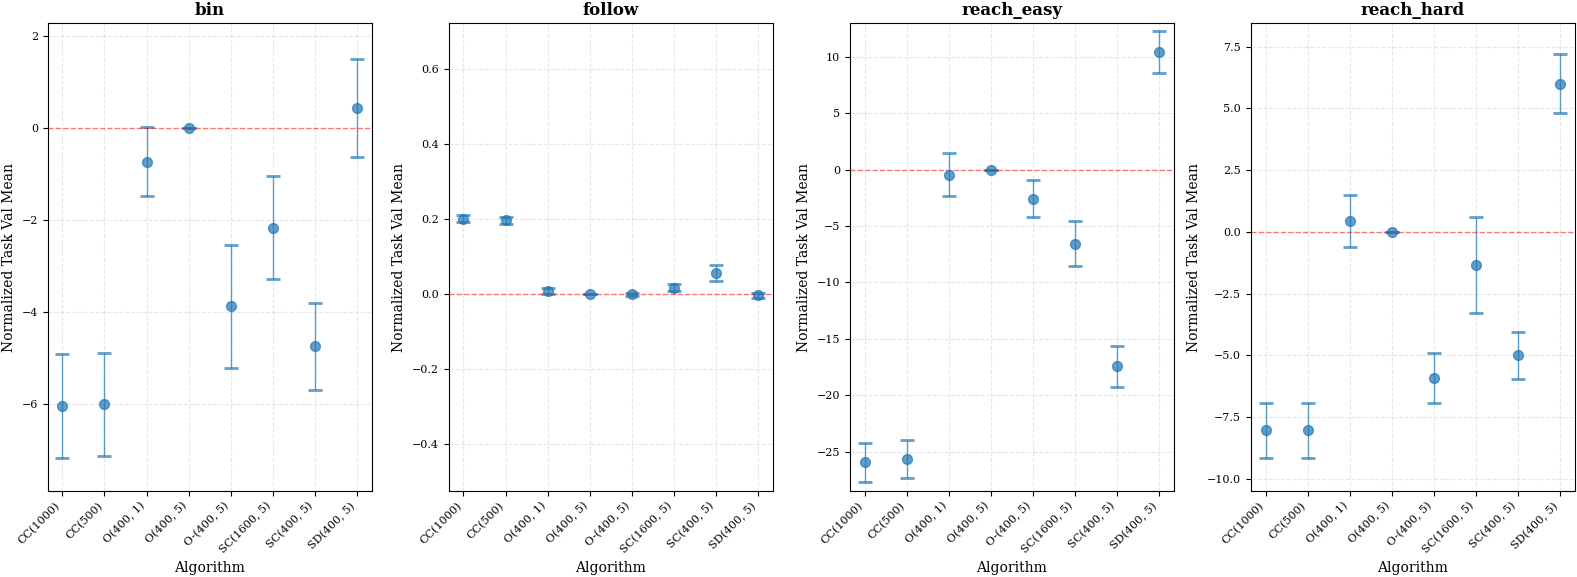

In [20]:
plot_algorithm_comparison_with_ci(df_plot)

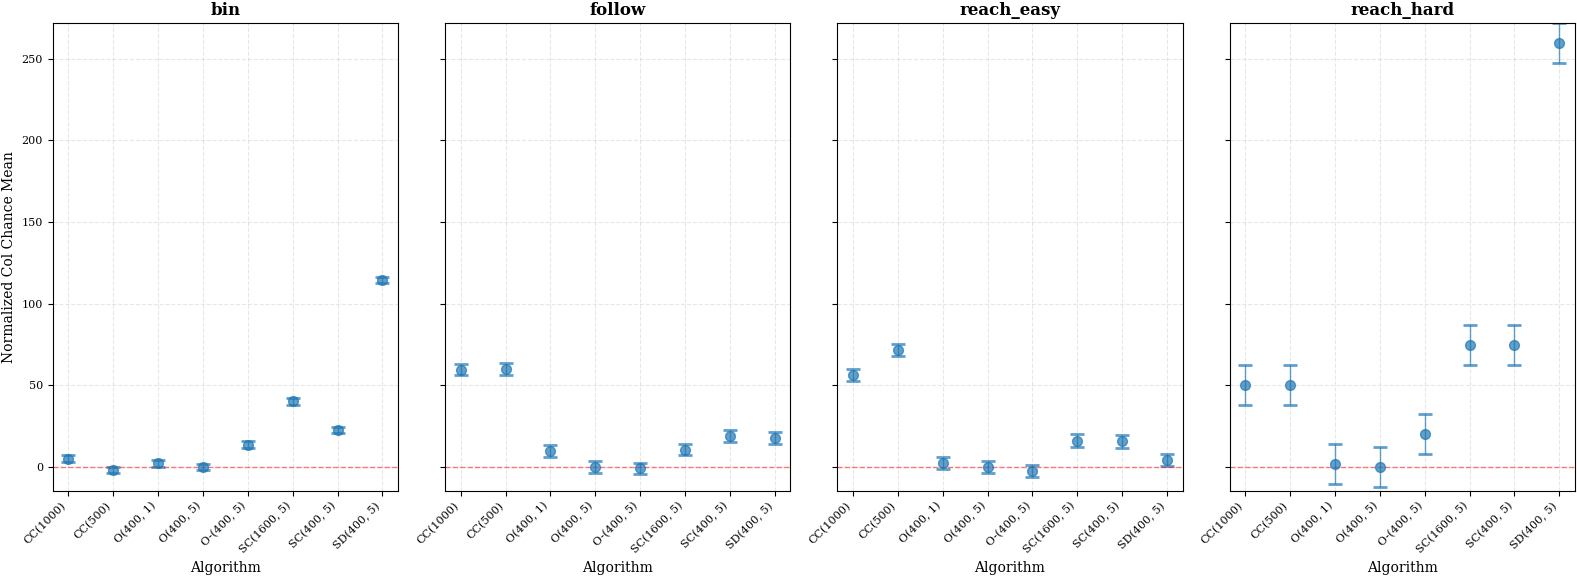

In [21]:
def plot_col_chance_comparison_with_ci(df, show_cols_as_chance_per_step, sim_step_num,confidence_level=0.95,fixed_y_limits_cols=True):
    """
    Create 4 subplots showing algorithm comparison for normalized_col_chance with confidence intervals.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: 'task_type', 'alg', 'normalized_col_chance_mean', 'baseline_col_chance_std', 'count'
    confidence_level : float
        Confidence level for the intervals (default 0.95 for 95% CI)
    show_cols_as_chance_per_step : bool
        If True, multiply values by 500 to show collision chance per step.
        If False, keep original normalized values.
    """
    # Get unique task types
    task_types = df['task_type'].unique()
    n_task_types = len(task_types)
    
    # Create subplots with shared y-axis
    fig, axes = plt.subplots(1, n_task_types, figsize=(4*n_task_types, 6), sharey=True)
    if n_task_types == 1:
        axes = [axes]
    
    # Calculate confidence interval multiplier (assuming normal distribution)
    z_scores = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    z = z_scores.get(confidence_level, 1.96)
    
    # First pass: collect all data to determine global y-axis limits
    all_means = []
    all_ci_half_widths = []
    
    for task_type in task_types:
        task_data = df[df['task_type'] == task_type].copy()
        task_data = task_data.sort_values('alg')
        
        means = task_data['normalized_col_chance_mean'].tolist()
        stds = task_data['baseline_col_chance_std'].tolist()
        counts = task_data['count'].tolist()
        
        # Apply scaling if requested
        if not show_cols_as_chance_per_step:
            means = [mean * sim_step_num for mean in means]
            stds = [std * sim_step_num for std in stds]
        
        ci_half_widths = [z * (std / np.sqrt(count)) for std, count in zip(stds, counts)]
        
        all_means.extend(means)
        all_ci_half_widths.extend(ci_half_widths)
    
    # Calculate global y-axis limits
    global_y_min = min(all_means) - max(all_ci_half_widths) - 0.01
    global_y_max = max(all_means) + max(all_ci_half_widths) + 0.01
    
    # Second pass: create plots
    for i, task_type in enumerate(task_types):
        ax = axes[i]
        
        # Filter data for this task type
        task_data = df[df['task_type'] == task_type].copy()
        
        # Sort by algorithm name for consistent ordering
        task_data = task_data.sort_values('alg')
        
        # Get data
        algs = task_data['alg'].tolist()
        means = task_data['normalized_col_chance_mean'].tolist()
        stds = task_data['baseline_col_chance_std'].tolist()
        counts = task_data['count'].tolist()
        
        # Apply scaling if requested
        if not show_cols_as_chance_per_step:
            means = [mean * sim_step_num for mean in means]
            stds = [std * sim_step_num for std in stds]
        
        # Calculate confidence intervals
        ci_half_widths = [z * (std / np.sqrt(count)) for std, count in zip(stds, counts)]
        
        # Create x positions
        x_pos = range(len(algs))
        
        # Plot points
        ax.scatter(x_pos, means, s=50, alpha=0.7, zorder=3)
        
        # Plot confidence intervals as error bars
        ax.errorbar(x_pos, means, yerr=ci_half_widths, 
                   fmt='none', capsize=5, capthick=2, 
                   alpha=0.7, zorder=2)
        
        # Customize subplot
        ax.set_title(f'{task_type}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Algorithm', fontsize=10)
        if i == 0:  # Only show y-label on the leftmost subplot
            y_label = 'Collision Chance per Step' if show_cols_as_chance_per_step else 'Normalized Col Chance Mean'
            ax.set_ylabel(y_label, fontsize=10)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(algs, rotation=45, ha='right')
        ax.grid(True, alpha=0.3)
        
        # Add horizontal line at y=0 for reference
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        
        # Set global y-axis limits
        if not fixed_y_limits_cols:
            ax.set_ylim(global_y_min, global_y_max)
        else:
            if show_cols_as_chance_per_step:
                ax.set_ylim(0, 1)
            else:
                ax.set_ylim(0, sim_step_num)
    plt.tight_layout()
    plt.show()

# Usage examples:
# Show collision chance per step (multiplied by 500)
# plot_col_chance_comparison_with_ci(df, show_cols_as_chance_per_step=True)

# Show normalized values (original behavior)
plot_col_chance_comparison_with_ci(df_plot, show_cols_as_chance_per_step=False,sim_step_num=500,fixed_y_limits_cols=False)

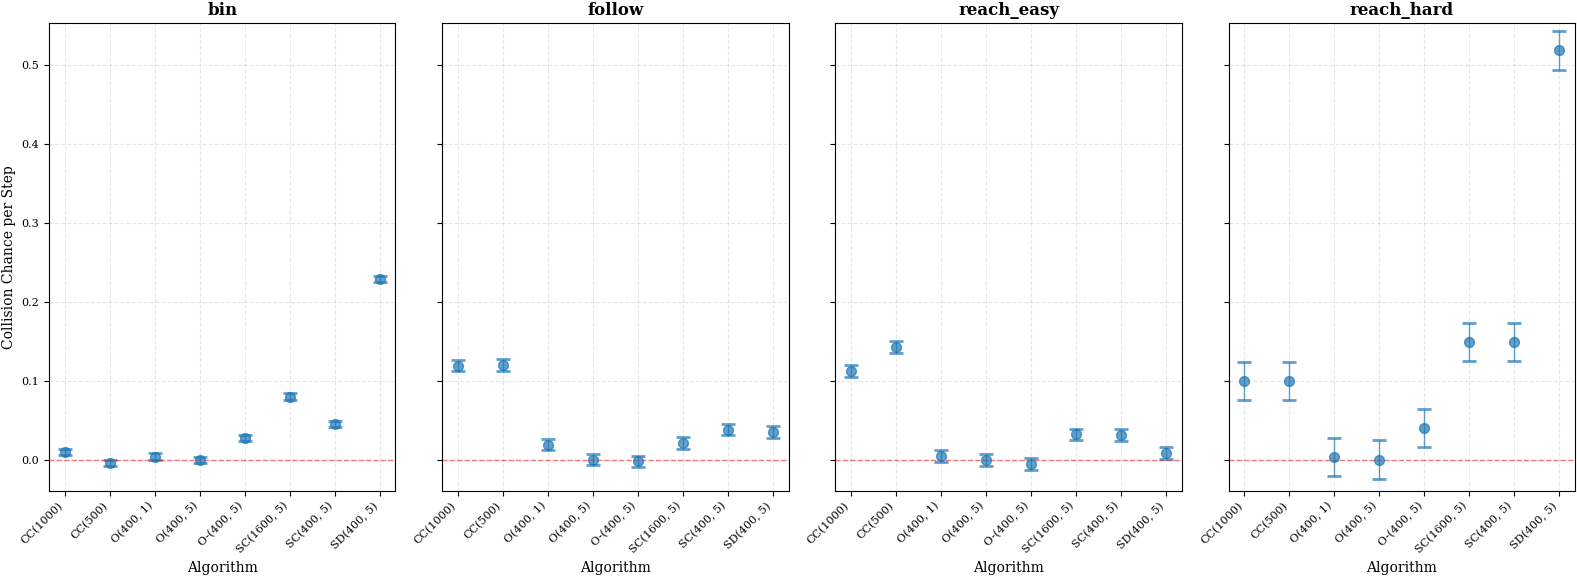

In [22]:
plot_col_chance_comparison_with_ci(df_plot, show_cols_as_chance_per_step=True,sim_step_num=500,fixed_y_limits_cols=False)

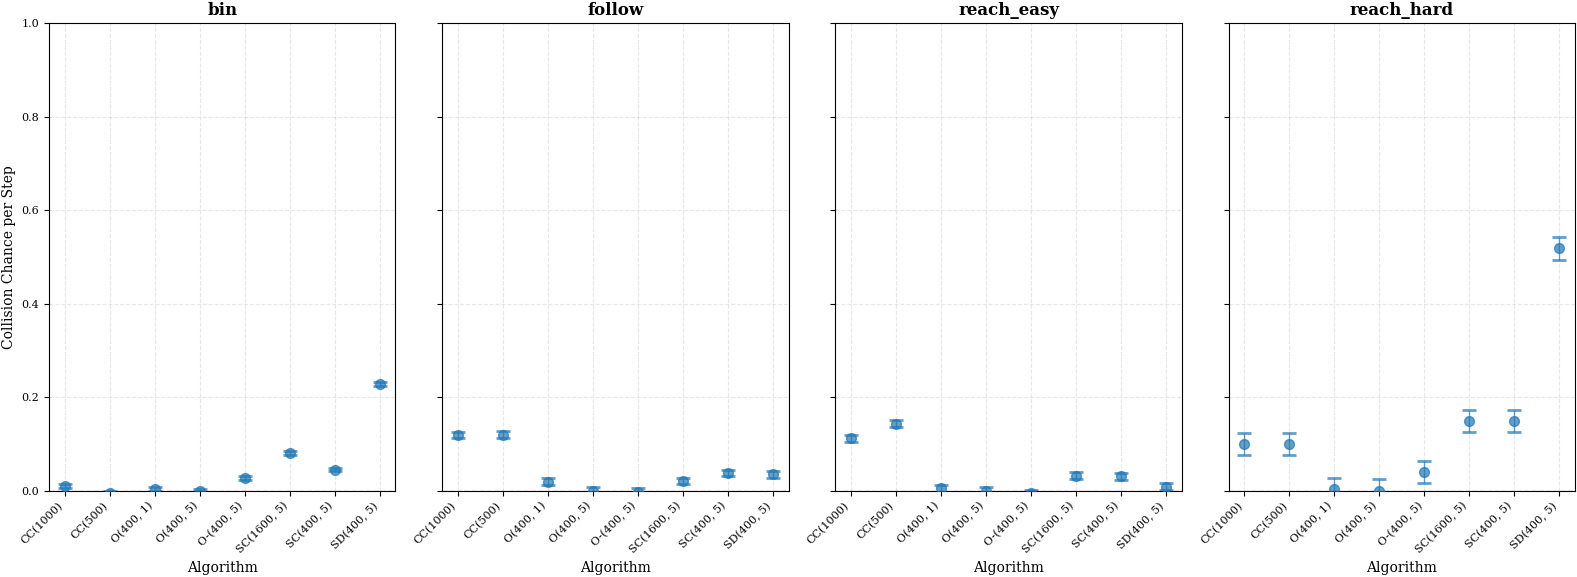

In [23]:
plot_col_chance_comparison_with_ci(df_plot, show_cols_as_chance_per_step=True,sim_step_num=500,fixed_y_limits_cols=True)

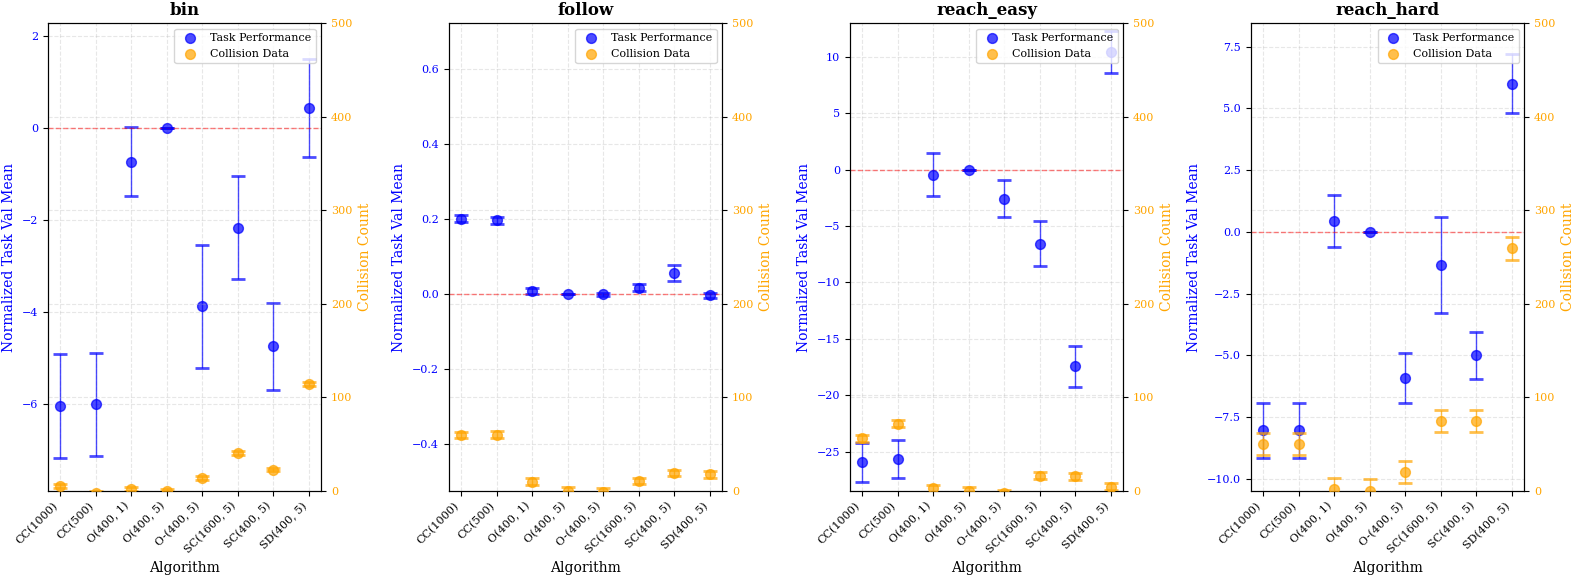

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# def plot_combined_algorithm_comparison_with_ci(df_task, df_col, confidence_level=0.95, 
#                                             show_cols_as_chance_per_step=True, sim_step_num=500,
#                                             fixed_y_limits_cols=True):
#     """
#     Create 4 subplots showing both task performance and collision data with dual y-axes.
    
#     Parameters:
#     -----------
#     df_task : pandas.DataFrame
#         DataFrame with task data: 'task_type', 'alg', 'normalized_task_val_mean', 'normalized_task_val_std', 'count'
#     df_col : pandas.DataFrame
#         DataFrame with collision data: 'task_type', 'alg', 'normalized_col_chance_mean', 'baseline_col_chance_std', 'count'
#     confidence_level : float
#         Confidence level for the intervals (default 0.95 for 95% CI)
#     show_cols_as_chance_per_step : bool
#         If True, multiply collision values by sim_step_num to show collision chance per step.
#         If False, keep original normalized values.
#     sim_step_num : int
#         Number of simulation steps (default 500)
#     fixed_y_limits_cols : bool
#         Whether to use fixed y-axis limits for collision data
#     """
#     # Get unique task types
#     task_types = df_task['task_type'].unique()
#     n_task_types = len(task_types)
    
#     # Create subplots
#     fig, axes = plt.subplots(1, n_task_types, figsize=(4*n_task_types, 6))
#     if n_task_types == 1:
#         axes = [axes]
    
#     # Calculate confidence interval multiplier
#     z_scores = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
#     z = z_scores.get(confidence_level, 1.96)
    
#     for i, task_type in enumerate(task_types):
#         ax_left = axes[i]  # Left y-axis for task data
        
#         # Filter task data for this task type
#         task_data = df_task[df_task['task_type'] == task_type].copy()
#         task_data = task_data.sort_values('alg')
        
#         # Get task data
#         algs = task_data['alg'].tolist()
#         task_means = task_data['normalized_task_val_mean'].tolist()
#         task_stds = task_data['normalized_task_val_std'].tolist()
#         task_counts = task_data['count'].tolist()
        
#         # Calculate task confidence intervals
#         task_ci_half_widths = [z * (std / np.sqrt(count)) for std, count in zip(task_stds, task_counts)]
        
#         # Create x positions
#         x_pos = range(len(algs))
        
#         # Plot task data on left y-axis
#         ax_left.scatter(x_pos, task_means, s=50, alpha=0.7, zorder=3, color='blue', label='Task Performance')
#         ax_left.errorbar(x_pos, task_means, yerr=task_ci_half_widths, 
#                         fmt='none', capsize=5, capthick=2, 
#                         alpha=0.7, zorder=2, color='blue')
        
#         # Customize left y-axis
#         ax_left.set_ylabel('Normalized Task Val Mean', fontsize=10, color='blue')
#         ax_left.tick_params(axis='y', labelcolor='blue')
        
#         # Add horizontal line at y=0 for task data
#         ax_left.axhline(y=0, color='red', linestyle='--', alpha=0.5)
        
#         # Set task y-axis limits
#         task_y_min = min(task_means) - max(task_ci_half_widths) - 0.5
#         task_y_max = max(task_means) + max(task_ci_half_widths) + 0.5
#         ax_left.set_ylim(task_y_min, task_y_max)
        
#         # Create right y-axis for collision data
#         ax_right = ax_left.twinx()
        
#         # Filter collision data for this task type
#         col_data = df_col[df_col['task_type'] == task_type].copy()
#         col_data = col_data.sort_values('alg')
        
#         # Get collision data
#         col_means = col_data['normalized_col_chance_mean'].tolist()
#         col_stds = col_data['baseline_col_chance_std'].tolist()
#         col_counts = col_data['count'].tolist()
        
#         # Apply scaling if requested
#         if not show_cols_as_chance_per_step:
#             col_means = [mean * sim_step_num for mean in col_means]
#             col_stds = [std * sim_step_num for std in col_stds]
        
#         # Calculate collision confidence intervals
#         col_ci_half_widths = [z * (std / np.sqrt(count)) for std, count in zip(col_stds, col_counts)]
        
#         # Plot collision data on right y-axis
#         ax_right.scatter(x_pos, col_means, s=50, alpha=0.7, zorder=3, color='orange', label='Collision Data')
#         ax_right.errorbar(x_pos, col_means, yerr=col_ci_half_widths, 
#                          fmt='none', capsize=5, capthick=2, 
#                          alpha=0.7, zorder=2, color='orange')
        
#         # Customize right y-axis
#         col_y_label = 'Collision Chance per Step' if show_cols_as_chance_per_step else 'Collision Count'
#         ax_right.set_ylabel(col_y_label, fontsize=10, color='orange')
#         ax_right.tick_params(axis='y', labelcolor='orange')
        
#         # Set collision y-axis limits
#         if fixed_y_limits_cols:
#             if show_cols_as_chance_per_step:
#                 ax_right.set_ylim(0, 1)
#             else:
#                 ax_right.set_ylim(0, sim_step_num)
#         else:
#             col_y_min = min(col_means) - max(col_ci_half_widths) - 0.01
#             col_y_max = max(col_means) + max(col_ci_half_widths) + 0.01
#             ax_right.set_ylim(col_y_min, col_y_max)
        
#         # Customize subplot
#         ax_left.set_title(f'{task_type}', fontsize=12, fontweight='bold')
#         ax_left.set_xlabel('Algorithm', fontsize=10)
#         ax_left.set_xticks(x_pos)
#         ax_left.set_xticklabels(algs, rotation=45, ha='right')
#         ax_left.grid(True, alpha=0.3)
        
#         # Add legend
#         lines1, labels1 = ax_left.get_legend_handles_labels()
#         lines2, labels2 = ax_right.get_legend_handles_labels()
#         ax_left.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    
#     plt.tight_layout()
#     plt.show()

# # Usage example:
# plot_combined_algorithm_comparison_with_ci(df_plot, df_plot, 
#                                          show_cols_as_chance_per_step=False, 
#                                          sim_step_num=500, 
#                                          fixed_y_limits_cols=True)

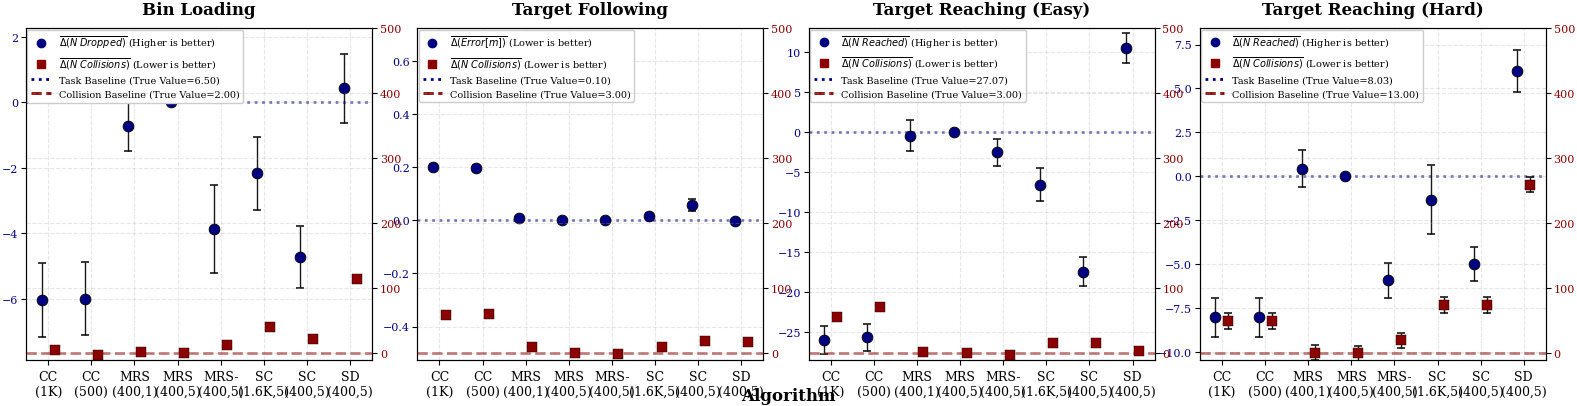

In [34]:
# import matplotlib.pyplot as plt
# import numpy as np

# def plot_combined_algorithm_comparison_with_ci(df_task, df_col, confidence_level=0.95, 
#                                             show_cols_as_chance_per_step=True, sim_step_num=500,
#                                             fixed_y_limits_cols=True, save_path=None):
#     """
#     Create 4 subplots showing both task performance and collision data with dual y-axes.
#     Styled for academic conference papers.
#     """
#     # Apply paper-ready style
#     plt.rcParams.update({
#     "figure.figsize": (13, 4),  # Will be adjusted for square subplots
#     "font.size": 9,
#     "font.family": "serif",
#     "font.weight": "normal",  # ADD THIS LINE
#     "axes.labelsize": 9,
#     "axes.titlesize": 10,
#     "xtick.labelsize": 8,
#     "ytick.labelsize": 8,
#     "legend.fontsize": 8,
#     "lines.linewidth": 1,
#     "axes.grid": True,
#     "grid.linestyle": "--",
#     "grid.alpha": 0.3,
#     "savefig.bbox": "tight",
#     "savefig.pad_inches": 0.02,
#     "savefig.format": "pdf"
# })
    
#     # Get unique task types
#     task_types = df_task['task_type'].unique()
#     n_task_types = len(task_types)
    
#     # Calculate square subplot size - make each subplot square
#     subplot_size = 4  # Height of each subplot
#     fig_width = n_task_types * subplot_size  # Total width = number of subplots * subplot size
#     fig_height = subplot_size  # Height = subplot size (square)
    
#     # Create subplots with square aspect ratio
#     fig, axes = plt.subplots(1, n_task_types, figsize=(fig_width, fig_height))
#     if n_task_types == 1:
#         axes = [axes]
    
#     # Calculate confidence interval multiplier
#     z_scores = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
#     z = z_scores.get(confidence_level, 1.96)
    
#     # Define colors and markers for consistency
#     task_color = 'navy' # 'gray'
#     col_color = 'darkred'    
#     task_marker = 'o'
#     col_marker = 's'
#     line_style_task = 'dotted'
#     line_style_col = '--'
    
#     # Define task-specific y-labels
#     task_y_labels = {
#         'bin': fr'$\overline{{\Delta(N\; Dropped)}}$' + ' (Higher is better)',
#         'reach_easy':fr'$\overline{{\Delta(N\; Reached)}}$' + ' (Higher is better)', 
#         'reach_hard':fr'$\overline{{\Delta(N\; Reached)}}$'+ ' (Higher is better)',
#         'follow':fr'$\overline{{\Delta(Error[m])}}$' + ' (Lower is better)' 
#     }
    
#     # Store baseline values for legend
#     baseline_values = {}
    
#     # First pass: collect all collision data to determine shared y-axis limits when fixed_y_limits_cols=True
#     all_col_means = []
#     all_col_ci_half_widths = []
    
#     if fixed_y_limits_cols:
#         for task_type in task_types:
#             col_data = df_col[df_col['task_type'] == task_type].copy()
#             col_data = col_data.sort_values('alg')
            
#             col_means = col_data['normalized_col_chance_mean'].tolist()
#             col_stds = col_data['baseline_col_chance_std'].tolist()
#             col_counts = col_data['count'].tolist()
            
#             # Apply scaling if requested
#             if not show_cols_as_chance_per_step:
#                 col_means = [mean * sim_step_num for mean in col_means]
#                 col_stds = [std * sim_step_num for std in col_stds]
            
#             col_ci_half_widths = [z * (std / np.sqrt(count)) for std, count in zip(col_stds, col_counts)]
            
#             all_col_means.extend(col_means)
#             all_col_ci_half_widths.extend(col_ci_half_widths)
        
#         # Calculate shared collision y-axis limits
#         if show_cols_as_chance_per_step:
#             shared_col_y_min = 0
#             shared_col_y_max = 1
#         else:
#             shared_col_y_min = -10
#             shared_col_y_max = sim_step_num
    
#     for i, task_type in enumerate(task_types):
#         ax_left = axes[i]
        
#         # Filter task data for this task type
#         task_data = df_task[df_task['task_type'] == task_type].copy()
#         task_data = task_data.sort_values('alg')
        
#         # Get task data
#         algs = task_data['alg'].tolist()
#         task_means = task_data['normalized_task_val_mean'].tolist()
#         task_stds = task_data['normalized_task_val_std'].tolist()
#         task_counts = task_data['count'].tolist()
        
#         # Calculate task confidence intervals
#         task_ci_half_widths = [z * (std / np.sqrt(count)) for std, count in zip(task_stds, task_counts)]
        
#         # Create x positions with offset
#         x_pos = range(len(algs))
#         x_pos_task = [x - 0.15 for x in x_pos]  # Offset circles to the left
#         x_pos_col = [x + 0.15 for x in x_pos]   # Offset squares to the right
        
#         # Plot task data on left y-axis - OFFSET TO LEFT
#         ax_left.scatter(x_pos_task, task_means, s=60, alpha=1.0, zorder=4, 
#                        color=task_color, marker=task_marker, edgecolors='black', linewidth=0.6,
#                        label='Task Performance')
#         ax_left.errorbar(x_pos_task, task_means, yerr=task_ci_half_widths, 
#                         fmt='none', capsize=3, capthick=1.2, 
#                         alpha=0.9, zorder=3, color='black', linewidth=1.0)
        
#         # Customize left y-axis - TASK-SPECIFIC LABELS WITH REDUCED PADDING
#         task_y_label = task_y_labels.get(task_type, 'Task Performance')
#         # ax_left.set_ylabel(task_y_label, fontsize=9, color=task_color, fontweight='bold', labelpad=-2)
#         ax_left.tick_params(axis='y', labelcolor=task_color, labelsize=8, pad=2)  # REDUCED PAD
        
#         # Add horizontal line at y=0 for task data (baseline) - CLEAN STYLE
#         ax_left.axhline(y=0, color=task_color, linestyle=line_style_task, alpha=0.5, linewidth=2.0, zorder=5)
        
#         # Store baseline value for legend
#         baseline_values[task_type] = {'task': 0, 'collision': None}
        
#         # Set task y-axis limits
#         task_y_min = min(task_means) - max(task_ci_half_widths) - 0.5
#         task_y_max = max(task_means) + max(task_ci_half_widths) + 0.5
#         ax_left.set_ylim(task_y_min, task_y_max)
        
#         # Create right y-axis for collision data
#         ax_right = ax_left.twinx()
        
#         # Filter collision data for this task type
#         col_data = df_col[df_col['task_type'] == task_type].copy()
#         col_data = col_data.sort_values('alg')
        
#         # Get collision data
#         col_means = col_data['normalized_col_chance_mean'].tolist()
#         col_stds = col_data['baseline_col_chance_std'].tolist()
#         col_counts = col_data['count'].tolist()
        
#         # Apply scaling if requested
#         if not show_cols_as_chance_per_step:
#             col_means = [mean * sim_step_num for mean in col_means]
#             col_stds = [std * sim_step_num for std in col_stds]
        
#         # Calculate collision confidence intervals
#         col_ci_half_widths = [z * (std / np.sqrt(count)) for std, count in zip(col_stds, col_counts)]
        
#         # Plot collision data on right y-axis - OFFSET TO RIGHT
#         ax_right.scatter(x_pos_col, col_means, s=60, alpha=1.0, zorder=4, 
#                         color=col_color, marker=col_marker, edgecolors='black', linewidth=0.3,
#                         label='Collision Risk')
#         ax_right.errorbar(x_pos_col, col_means, yerr=col_ci_half_widths, 
#                          fmt='none', capsize=3, capthick=1.2, 
#                          alpha=0.9, zorder=3, color='black', linewidth=1.0)
        
#         # Add horizontal baseline line for collision data (O(400,5) value)
#         # Find O(400,5) collision value for this task type
#         o400_5_col_data = col_data[col_data['alg'] == 'O(400, 5)']
#         if not o400_5_col_data.empty:
#             o400_5_col_value = o400_5_col_data['normalized_col_chance_mean'].iloc[0]
#             if not show_cols_as_chance_per_step:
#                 o400_5_col_value = o400_5_col_value * sim_step_num
#             # Clean collision baseline
#             ax_right.axhline(y=o400_5_col_value, color=col_color, linestyle=line_style_col, alpha=0.5, linewidth=2.0, zorder=5)
#             # Store baseline value for legend
#             baseline_values[task_type]['collision'] = o400_5_col_value
        
#         # Set collision y-axis limits - SHARED ACROSS ALL SUBPLOTS WHEN fixed_y_limits_cols=True
#         if fixed_y_limits_cols:
#             ax_right.set_ylim(shared_col_y_min, shared_col_y_max)
#         else:
#             col_y_min = min(col_means) - max(col_ci_half_widths) - 0.01
#             col_y_max = max(col_means) + max(col_ci_half_widths) + 0.01
#             ax_right.set_ylim(col_y_min, col_y_max)
        
#         # ADD GRID FOR COLLISIONS TO ALL SUBPLOTS - APPLY SAME SCALE
#         ax_right.grid(True, alpha=0.3, linestyle='--')
        
#         # Customize right y-axis - SHOW Y-AXIS TICK LABELS ON ALL SUBPLOTS
#         col_y_label = 'Collision Risk' if show_cols_as_chance_per_step else 'Collision Count'
#         # Show y-axis tick labels on ALL subplots for collision data
#         ax_right.tick_params(axis='y', labelcolor=col_color, labelsize=8, pad=2)  # REDUCED PAD
        
#         # Customize subplot
#         task_to_title = {
#             'bin': 'Bin Loading',
#             'reach_easy': 'Target Reaching (Easy)',
#             'reach_hard': 'Target Reaching (Hard)',
#             'follow': 'Target Following'
#         }
        
#         # Add horizontal line above the title using plot instead of axhline
#         ax_left.plot([0, 1], [1.05, 1.05], color='black', linewidth=1.5, 
#                     transform=ax_left.transAxes, zorder=10)
        
#         ax_left.set_title(task_to_title[task_type], fontsize=12, fontweight='bold', pad=10, color='black')
        
#         # FIXED: Algorithm names with proper alignment and shortened names
#         alg_short_names = {
#             'O(400, 1)': 'MRS\n(400,1)',
#             'O(400, 5)': 'MRS\n(400,5)', 
#             'O-(400, 5)': 'MRS-\n(400,5)',
#             'CC(1000)': 'CC\n(1K)',
#             'CC(500)': 'CC\n(500)',
#             'SC(400, 5)': 'SC\n(400,5)',
#             'SC(1600, 5)': 'SC\n(1.6K,5)',
#             'SD(400, 5)': 'SD\n(400,5)',
#         }
        
#         ax_left.set_xticks(x_pos)
        
#         # Create x-axis labels with MRS(5) highlighted in bold
#         labels = [alg_short_names.get(alg, alg) for alg in algs]
#         # labels = [f"$\\bf{{{lab}}}$" if lab.startswith("MRS\n(5)") else lab for lab in labels]  # ✅ bold MRS(5)
#         ax_left.set_xticklabels(labels, rotation=0, ha='center', fontsize=9)
#         ax_left.grid(True, alpha=0.3, linestyle='--')
        
#         # ADD LEGEND FOR EACH SUBPLOT WITH REAL BASELINE VALUES
#         # Get the first row of data for this task type to extract baseline values
#         first_row = task_data.iloc[0]
#         baseline_task_val = first_row['baseline_task_val_mean']
#         baseline_col_chance = first_row['baseline_col_chance_mean']
        
#         # Apply scaling to collision baseline if needed
#         if not show_cols_as_chance_per_step:
#             baseline_col_chance = baseline_col_chance * sim_step_num
        
#         # Create legend elements for this subplot
#         legend_elements = []
        
#         # Add data series
#         legend_elements.append(plt.Line2D([0], [0], marker='o', color=task_color, linestyle='None', 
#                                         markersize=6, label=task_y_labels[task_type]))# label=r'$\Delta$' + ' Task Metric'))
#         legend_elements.append(plt.Line2D([0], [0], marker='s', color=col_color, linestyle='None', 
#                                         markersize=6, label=fr'$\overline{{\Delta(N\; Collisions)}}$' + ' (Lower is better)'))
        
#         # Add baseline lines with real values
#         legend_elements.append(plt.Line2D([0], [0], color=task_color, linestyle=line_style_task, linewidth=2, 
#                                         label=f'Task Baseline (True Value={baseline_task_val:.2f})'))
#         legend_elements.append(plt.Line2D([0], [0], color=col_color, linestyle=line_style_col, linewidth=2, 
#                                         label=f'Collision Baseline (True Value={baseline_col_chance:.2f})'))
        
#         # Add legend to this subplot
#         # ax_left.legend(handles=legend_elements, loc='upper left', fontsize=7, framealpha=0.9)
#         ax_left.legend(handles=legend_elements, loc='upper left', fontsize=7, framealpha=1.0,
#                bbox_to_anchor=(-0.01, 1.01))  # Small adjustments
#     # Add single "Algorithm" label at the bottom of all subplots - PROPERLY POSITIONED
#     fig.text(0.5, 0.01, 'Algorithm', ha='center', va='bottom', fontsize=12, fontweight='bold',)
    
#     # Adjust layout with smaller gaps between subplots and reduced bottom margin
#     plt.tight_layout()
#     if fixed_y_limits_cols:
#         plt.subplots_adjust(bottom=0.12, wspace=0.13, top=0.95)  # Added top margin for horizontal legend
#     else:
#         plt.subplots_adjust(bottom=0.12, wspace=0.3, top=0.85)  # Added top margin for horizontal legend
    
#     # Save if path provided
#     if save_path:
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
#     plt.show()

# plot_combined_algorithm_comparison_with_ci(df_plot, df_plot, 
#                                          show_cols_as_chance_per_step=False, 
#                                          sim_step_num=500, 
#                                          fixed_y_limits_cols=True,
#                                          save_path='combined_analysis.pdf'
# )

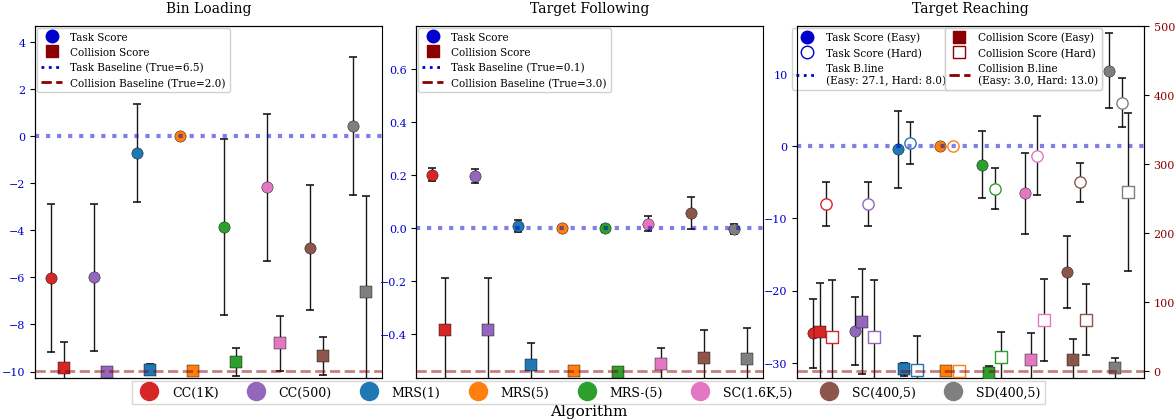

In [113]:
import matplotlib.pyplot as plt
import numpy as np

def plot_combined_algorithm_comparison_with_ci_v3(df_task, df_col, confidence_level=0.95, 
                                            show_cols_as_chance_per_step=True, sim_step_num=500,
                                            fixed_y_limits_cols=True, save_path=None):
    """
    Create 3 subplots showing both task performance and collision data with dual y-axes.
    Combines target reaching easy and hard on the same subplot.
    Styled for academic conference papers. Each algorithm gets a unique color.
    """
    # Apply paper-ready style
    plt.rcParams.update({
    "figure.figsize": (13, 4),  # Will be adjusted for square subplots
    "font.size": 9,
    "font.family": "serif",
    "font.weight": "normal",  # ADD THIS LINE
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "lines.linewidth": 1,
    "axes.grid": True,
    "grid.linestyle": "",
    # "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "savefig.format": "pdf"
})
    
    # Get unique task types and combine reaching easy and hard
    task_types = df_task['task_type'].unique()
    # Remove reach_easy and reach_hard from individual processing
    individual_task_types = [t for t in task_types if t not in ['reach_easy', 'reach_hard']]
    # Add combined reaching task
    if 'reach_easy' in task_types or 'reach_hard' in task_types:
        individual_task_types.append('reach_combined')
    
    n_task_types = len(individual_task_types)
    
    # Calculate square subplot size - make each subplot square
    subplot_size = 4  # Height of each subplot
    fig_width = n_task_types * subplot_size  # Total width = number of subplots * subplot size
    fig_height = subplot_size  # Height = subplot size (square)
    
    # Create subplots with square aspect ratio
    fig, axes = plt.subplots(1, n_task_types, figsize=(fig_width, fig_height))
    if n_task_types == 1:
        axes = [axes]
    
    # Calculate confidence interval multiplier
    # z_scores = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    #z = z_scores.get(confidence_level, 1.96)
    
    # Define unique colors for each algorithm
    alg_colors = {
        'O(400, 1)': '#1f77b4',    # Blue
        'O(400, 5)': '#ff7f0e',    # Orange
        'O-(400, 5)': '#2ca02c',   # Green
        'CC(1000)': '#d62728',      # Red
        'CC(500)': '#9467bd',       # Purple
        'SC(400, 5)': '#8c564b',    # Brown
        'SC(1600, 5)': '#e377c2',   # Pink
        'SD(400, 5)': '#7f7f7f',    # Gray
    }
    
    # Define colors for baselines
    task_baseline_color = 'mediumblue'
    col_baseline_color = 'darkred'
    
    # Define markers for task vs collision data
    task_marker = 'o'
    col_marker = 's'
    line_style_task = 'dotted'
    line_style_col = '--'
    
    # Define task-specific y-labels
    task_y_labels = {
        'bin': 'Task Score',
        'reach_combined': 'Task Score',
        'follow': 'Task Score' 
    }
    
    # Store baseline values for legend
    baseline_values = {}
    
    # First pass: collect all collision data to determine shared y-axis limits when fixed_y_limits_cols=True
    all_col_means = []
    all_col_ci_half_widths = []
    
    if fixed_y_limits_cols:
        for task_type in individual_task_types:
            if task_type == 'reach_combined':
                # Process both reach_easy and reach_hard
                for reach_type in ['reach_easy', 'reach_hard']:
                    if reach_type in df_col['task_type'].values:
                        col_data = df_col[df_col['task_type'] == reach_type].copy()
                        col_data = col_data.sort_values('alg')
                        
                        col_means = col_data['normalized_col_chance_mean'].tolist()
                        col_stds = col_data['baseline_col_chance_std'].tolist()
                        col_counts = col_data['count'].tolist()
                        
                        # Apply scaling if requested
                        if not show_cols_as_chance_per_step:
                            col_means = [mean * sim_step_num for mean in col_means]
                            col_stds = [std * sim_step_num for std in col_stds]
                        
                        # col_ci_half_widths = [z * (std / np.sqrt(count)) for std, count in zip(col_stds, col_counts)]
                        col_ci_half_widths = [std for std, count in zip(col_stds, col_counts)]
                        
                        all_col_means.extend(col_means)
                        all_col_ci_half_widths.extend(col_ci_half_widths)
            else:
                col_data = df_col[df_col['task_type'] == task_type].copy()
                col_data = col_data.sort_values('alg')
                
                col_means = col_data['normalized_col_chance_mean'].tolist()
                col_stds = col_data['baseline_col_chance_std'].tolist()
                col_counts = col_data['count'].tolist()
                
                # Apply scaling if requested
                if not show_cols_as_chance_per_step:
                    col_means = [mean * sim_step_num for mean in col_means]
                    col_stds = [std * sim_step_num for std in col_stds]
                
                # col_ci_half_widths = [z * (std / np.sqrt(count)) for std, count in zip(col_stds, col_counts)]
                col_ci_half_widths = [std for std, count in zip(col_stds, col_counts)]
                
                all_col_means.extend(col_means)
                all_col_ci_half_widths.extend(col_ci_half_widths)
        
        # Calculate shared collision y-axis limits
        if show_cols_as_chance_per_step:
            shared_col_y_min = 0
            shared_col_y_max = 1
        else:
            shared_col_y_min = -10
            shared_col_y_max = sim_step_num
    
    for i, task_type in enumerate(individual_task_types):
        ax_left = axes[i]
        
        # Handle combined reaching task
        if task_type == 'reach_combined':
            # Get data for both reach_easy and reach_hard
            task_data_easy = df_task[df_task['task_type'] == 'reach_easy'].copy() if 'reach_easy' in df_task['task_type'].values else None
            task_data_hard = df_task[df_task['task_type'] == 'reach_hard'].copy() if 'reach_hard' in df_task['task_type'].values else None
            col_data_easy = df_col[df_col['task_type'] == 'reach_easy'].copy() if 'reach_easy' in df_col['task_type'].values else None
            col_data_hard = df_col[df_col['task_type'] == 'reach_hard'].copy() if 'reach_hard' in df_col['task_type'].values else None
            
            # Use easy data as base if available, otherwise hard
            if task_data_easy is not None:
                task_data = task_data_easy.copy()
                col_data = col_data_easy.copy()
            else:
                task_data = task_data_hard.copy()
                col_data = col_data_hard.copy()
            
            task_data = task_data.sort_values('alg')
            col_data = col_data.sort_values('alg')
            
            # Get algorithms list
            algs = task_data['alg'].tolist()
            
            # Get task data for easy
            task_means_easy = task_data['normalized_task_val_mean'].tolist()
            task_stds_easy = task_data['normalized_task_val_std'].tolist()
            task_counts_easy = task_data['count'].tolist()
            
            # Get task data for hard
            if task_data_hard is not None:
                task_data_hard = task_data_hard.sort_values('alg')
                task_means_hard = task_data_hard['normalized_task_val_mean'].tolist()
                task_stds_hard = task_data_hard['normalized_task_val_std'].tolist()
                task_counts_hard = task_data_hard['count'].tolist()
            else:
                task_means_hard = [0] * len(algs)
                task_stds_hard = [0] * len(algs)
                task_counts_hard = [1] * len(algs)
            
            # Get collision data for easy
            col_means_easy = col_data['normalized_col_chance_mean'].tolist()
            col_stds_easy = col_data['normalized_col_chance_std'].tolist()
            col_counts_easy = col_data['count'].tolist()
            
            # Get collision data for hard
            if col_data_hard is not None:
                col_data_hard = col_data_hard.sort_values('alg')
                col_means_hard = col_data_hard['normalized_col_chance_mean'].tolist()
                col_stds_hard = col_data_hard['normalized_col_chance_std'].tolist()
                col_counts_hard = col_data_hard['count'].tolist()
            else:
                col_means_hard = [0] * len(algs)
                col_stds_hard = [0] * len(algs)
                col_counts_hard = [1] * len(algs)
            
            # Apply scaling if requested
            if not show_cols_as_chance_per_step:
                col_means_easy = [mean * sim_step_num for mean in col_means_easy]
                col_stds_easy = [std * sim_step_num for std in col_stds_easy]
                col_means_hard = [mean * sim_step_num for mean in col_means_hard]
                col_stds_hard = [std * sim_step_num for std in col_stds_hard]
            
            # Calculate confidence intervals
            # task_ci_half_widths_easy = [z * (std / np.sqrt(count)) for std, count in zip(task_stds_easy, task_counts_easy)]
            # task_ci_half_widths_hard = [z * (std / np.sqrt(count)) for std, count in zip(task_stds_hard, task_counts_hard)]
            # col_ci_half_widths_easy = [z * (std / np.sqrt(count)) for std, count in zip(col_stds_easy, col_counts_easy)]
            # col_ci_half_widths_hard = [z * (std / np.sqrt(count)) for std, count in zip(col_stds_hard, col_counts_hard)]
            task_ci_half_widths_easy = [std for std, count in zip(task_stds_easy, task_counts_easy)]
            task_ci_half_widths_hard = [std for std, count in zip(task_stds_hard, task_counts_hard)]
            col_ci_half_widths_easy = [std for std, count in zip(col_stds_easy, col_counts_easy)]
            col_ci_half_widths_hard = [std for std, count in zip(col_stds_hard, col_counts_hard)]
            
            # Create x positions with offset for 4 data points per algorithm
            x_pos = range(len(algs))
            x_pos_task_easy = [x - 0.225 for x in x_pos]  # Leftmost
            x_pos_col_easy = [x - 0.075 for x in x_pos]   # Second from left
            x_pos_task_hard = [x + 0.075 for x in x_pos]  # Second from right
            x_pos_col_hard = [x + 0.225 for x in x_pos]   # Rightmost
            
            # Plot task data for easy (filled circles) - 10% BIGGER MARKERS
            for j, alg in enumerate(algs):
                color = alg_colors.get(alg, '#000000')
                ax_left.scatter(x_pos_task_easy[j], task_means_easy[j], s=66, alpha=1.0, zorder=4, 
                               color=color, marker=task_marker, edgecolors='black', linewidth=0.3)
                ax_left.errorbar(x_pos_task_easy[j], task_means_easy[j], yerr=task_ci_half_widths_easy[j], 
                                fmt='none', capsize=3, capthick=1.2, 
                                alpha=0.9, zorder=3, color='black', linewidth=1.0)
            
            # Plot task data for hard (empty circles) - 10% BIGGER MARKERS
            for j, alg in enumerate(algs):
                color = alg_colors.get(alg, '#000000')
                ax_left.scatter(x_pos_task_hard[j], task_means_hard[j], s=66, alpha=1.0, zorder=4, 
                               color='white', marker=task_marker, edgecolors=color, linewidth=1.0)
                ax_left.errorbar(x_pos_task_hard[j], task_means_hard[j], yerr=task_ci_half_widths_hard[j], 
                                fmt='none', capsize=3, capthick=1.2, 
                                alpha=0.9, zorder=3, color='black', linewidth=1.0)
            
            # Create right y-axis for collision data
            ax_right = ax_left.twinx()
            
            # Plot collision data for easy (filled squares) - 10% BIGGER MARKERS
            for j, alg in enumerate(algs):
                color = alg_colors.get(alg, '#000000')
                ax_right.scatter(x_pos_col_easy[j], col_means_easy[j], s=66, alpha=1.0, zorder=4, 
                                color=color, marker=col_marker, edgecolors='black', linewidth=0.3)
                ax_right.errorbar(x_pos_col_easy[j], col_means_easy[j], yerr=col_ci_half_widths_easy[j], 
                                 fmt='none', capsize=3, capthick=1.2, 
                                 alpha=0.9, zorder=3, color='black', linewidth=1.0)
            
            # Plot collision data for hard (empty squares) - 10% BIGGER MARKERS
            for j, alg in enumerate(algs):
                color = alg_colors.get(alg, '#000000')
                ax_right.scatter(x_pos_col_hard[j], col_means_hard[j], s=66, alpha=1.0, zorder=4, 
                                color='white', marker=col_marker, edgecolors=color, linewidth=1.0)
                ax_right.errorbar(x_pos_col_hard[j], col_means_hard[j], yerr=col_ci_half_widths_hard[j], 
                                 fmt='none', capsize=3, capthick=1.2, 
                                 alpha=0.9, zorder=3, color='black', linewidth=1.0)
            
            # Add horizontal line at y=0 for task data (baseline)
            ax_left.axhline(y=0, color=task_baseline_color, linestyle=line_style_task, alpha=0.5, linewidth=3, zorder=5)
            
            # Add horizontal baseline line for collision data (O(400,5) value)
            o400_5_col_data = col_data[col_data['alg'] == 'O(400, 5)']
            if not o400_5_col_data.empty:
                o400_5_col_value = o400_5_col_data['normalized_col_chance_mean'].iloc[0]
                if not show_cols_as_chance_per_step:
                    o400_5_col_value = o400_5_col_value * sim_step_num
                ax_right.axhline(y=o400_5_col_value, color=col_baseline_color, linestyle=line_style_col, alpha=0.5, linewidth=2.0, zorder=5)
            
            # Set y-axis limits
            task_y_min = min(min(task_means_easy), min(task_means_hard)) - max(max(task_ci_half_widths_easy), max(task_ci_half_widths_hard)) - 0.5
            task_y_max = max(max(task_means_easy), max(task_means_hard)) + max(max(task_ci_half_widths_easy), max(task_ci_half_widths_hard)) + 0.5
            ax_left.set_ylim(task_y_min, task_y_max)
            
            if fixed_y_limits_cols:
                ax_right.set_ylim(shared_col_y_min, shared_col_y_max)
            else:
                col_y_min = min(min(col_means_easy), min(col_means_hard)) - max(max(col_ci_half_widths_easy), max(col_ci_half_widths_hard)) - 0.01
                col_y_max = max(max(col_means_easy), max(col_means_hard)) + max(max(col_ci_half_widths_easy), max(col_ci_half_widths_hard)) + 0.01
                ax_right.set_ylim(col_y_min, col_y_max)
            
            # Customize y-axes
            ax_left.tick_params(axis='y', labelcolor=task_baseline_color, labelsize=8)
            
            # Only show y-axis tick labels on the rightmost subplot for collision data
            if i == n_task_types - 1:  # Rightmost subplot
                ax_right.tick_params(axis='y', labelcolor=col_baseline_color, labelsize=8)
            else:  # All other subplots - completely hide the right y-axis
                ax_right.tick_params(axis='y', labelleft=False, labelright=False, labelsize=8)
                ax_right.spines['right'].set_visible(False)
                ax_right.set_yticks([])
            
            # Set title
            ax_left.set_title('Target Reaching', fontsize=10, pad=10, color='black')
            
            # Add horizontal line above the title
            ax_left.plot([0, 1], [1.05, 1.05], color='black', linewidth=1.5, 
                        transform=ax_left.transAxes, zorder=10)
            
            # Remove x-axis labels
            ax_left.set_xticks([])
            ax_left.set_xticklabels([])
            
            # Create legend elements for this subplot with combined baseline info
            first_row_easy = task_data.iloc[0]
            baseline_task_val_easy = first_row_easy['baseline_task_val_mean']
            baseline_col_chance_easy = first_row_easy['baseline_col_chance_mean']
            
            # Get hard baseline values
            if task_data_hard is not None:
                first_row_hard = task_data_hard.iloc[0]
                baseline_task_val_hard = first_row_hard['baseline_task_val_mean']
            else:
                baseline_task_val_hard = 0
            
            if col_data_hard is not None:
                first_row_col_hard = col_data_hard.iloc[0]
                baseline_col_chance_hard = first_row_col_hard['baseline_col_chance_mean']
            else:
                baseline_col_chance_hard = 0
            
            # Apply scaling to collision baselines if needed
            if not show_cols_as_chance_per_step:
                baseline_col_chance_easy = baseline_col_chance_easy * sim_step_num
                baseline_col_chance_hard = baseline_col_chance_hard * sim_step_num
            
            # Create legend elements for this subplot - TWO ADJACENT COLUMNS
            legend_elements_col1 = []  # Column 1: Task elements
            legend_elements_col2 = []  # Column 2: Collision elements
            
            # Column 1: Task elements
            legend_elements_col1.append(plt.Line2D([0], [0], marker='o', color=task_baseline_color, linestyle='None', 
                                                 markersize=9, label='Task Score (Easy)'))
            legend_elements_col1.append(plt.Line2D([0], [0], marker='o', color='white', linestyle='None', 
                                                 markersize=9, markerfacecolor='white', markeredgecolor=task_baseline_color, 
                                                 markeredgewidth=1, label='Task Score (Hard)'))
            legend_elements_col1.append(plt.Line2D([0], [0], color=task_baseline_color, linestyle=line_style_task, linewidth=2, 
                                                 label=f'Task B.line\n(Easy: {baseline_task_val_easy:.1f}, Hard: {baseline_task_val_hard:.1f})'))
            
            # Column 2: Collision elements
            legend_elements_col2.append(plt.Line2D([0], [0], marker='s', color=col_baseline_color, linestyle='None', 
                                                 markersize=9, label='Collision Score (Easy)'))
            legend_elements_col2.append(plt.Line2D([0], [0], marker='s', color='white', linestyle='None', 
                                                 markersize=9, markerfacecolor='white', markeredgecolor=col_baseline_color, 
                                                 markeredgewidth=1, label='Collision Score (Hard)'))
            legend_elements_col2.append(plt.Line2D([0], [0], color=col_baseline_color, linestyle=line_style_col, linewidth=2, 
                                                 label=f'Collision B.line\n(Easy: {baseline_col_chance_easy:.1f}, Hard: {baseline_col_chance_hard:.1f})'))
            
            # Create two separate legends positioned adjacently
            legend1 = ax_left.legend(handles=legend_elements_col1, loc='upper left', fontsize=7.5, framealpha=0.9,
                           bbox_to_anchor=(-0.03, 1.01))# , title='Task', title_fontsize=8)
            legend2 = ax_left.legend(handles=legend_elements_col2, loc='upper left', fontsize=7.5, framealpha=0.9,
                           bbox_to_anchor=(0.41, 1.01))# , title='Collision', title_fontsize=8)
            
            # Add both legends to the plot
            ax_left.add_artist(legend1)
            ax_left.add_artist(legend2)
            
        else:
            # Handle individual task types (bin, follow, etc.)
            # Filter task data for this task type
            task_data = df_task[df_task['task_type'] == task_type].copy()
            task_data = task_data.sort_values('alg')
            
            # Get task data
            algs = task_data['alg'].tolist()
            task_means = task_data['normalized_task_val_mean'].tolist()
            task_stds = task_data['normalized_task_val_std'].tolist()
            task_counts = task_data['count'].tolist()
            
            # Calculate task confidence intervals
            # task_ci_half_widths = [z * (std / np.sqrt(count)) for std, count in zip(task_stds, task_counts)]
            task_ci_half_widths = [std for std, count in zip(task_stds, task_counts)]
            
            # Create x positions with offset
            x_pos = range(len(algs))
            x_pos_task = [x - 0.15 for x in x_pos]  # Offset circles to the left
            x_pos_col = [x + 0.15 for x in x_pos]   # Offset squares to the right
            
            # Plot task data on left y-axis - EACH ALGORITHM GETS UNIQUE COLOR - 10% BIGGER MARKERS
            for j, alg in enumerate(algs):
                color = alg_colors.get(alg, '#000000')  # Default to black if alg not found
                ax_left.scatter(x_pos_task[j], task_means[j], s=66, alpha=1.0, zorder=4, 
                               color=color, marker=task_marker, edgecolors='black', linewidth=0.3)
                ax_left.errorbar(x_pos_task[j], task_means[j], yerr=task_ci_half_widths[j], 
                                fmt='none', capsize=3, capthick=1.2, 
                                alpha=0.9, zorder=3, color='black', linewidth=1.0)
            
            # Customize left y-axis - TASK-SPECIFIC LABELS WITH COLORED TICK LABELS
            task_y_label = task_y_labels.get(task_type, 'Task Performance')
            ax_left.tick_params(axis='y', labelcolor=task_baseline_color, labelsize=8)  # CHANGED TO task_baseline_color
            
            # Add horizontal line at y=0 for task data (baseline) - CLEAN STYLE
            ax_left.axhline(y=0, color=task_baseline_color, linestyle=line_style_task, alpha=0.5, linewidth=3, zorder=5)
            
            # Store baseline value for legend
            baseline_values[task_type] = {'task': 0, 'collision': None}
            
            # Set task y-axis limits
            task_y_min = min(task_means) - max(task_ci_half_widths) - 0.5
            task_y_max = max(task_means) + max(task_ci_half_widths) + 0.5
            ax_left.set_ylim(task_y_min, task_y_max)
            
            # Create right y-axis for collision data
            ax_right = ax_left.twinx()
            
            # Filter collision data for this task type
            col_data = df_col[df_col['task_type'] == task_type].copy()
            col_data = col_data.sort_values('alg')
            
            # Get collision data
            col_means = col_data['normalized_col_chance_mean'].tolist()
            col_stds = col_data['normalized_col_chance_std'].tolist()
            col_counts = col_data['count'].tolist()
            
            # Apply scaling if requested
            if not show_cols_as_chance_per_step:
                col_means = [mean * sim_step_num for mean in col_means]
                col_stds = [std * sim_step_num for std in col_stds]
            
            # Calculate collision confidence intervals
            # col_ci_half_widths = [z * (std / np.sqrt(count)) for std, count in zip(col_stds, col_counts)]
            col_ci_half_widths = [std for std, count in zip(col_stds, col_counts)]
            # Plot collision data on right y-axis - EACH ALGORITHM GETS UNIQUE COLOR - 10% BIGGER MARKERS
            for j, alg in enumerate(algs):
                color = alg_colors.get(alg, '#000000')  # Default to black if alg not found
                ax_right.scatter(x_pos_col[j], col_means[j], s=66, alpha=1.0, zorder=4, 
                                color=color, marker=col_marker, edgecolors='black', linewidth=0.3)
                ax_right.errorbar(x_pos_col[j], col_means[j], yerr=col_ci_half_widths[j], 
                                 fmt='none', capsize=3, capthick=1.2, 
                                 alpha=0.9, zorder=3, color='black', linewidth=1.0)
            
            # Add horizontal baseline line for collision data (O(400,5) value)
            # Find O(400,5) collision value for this task type
            o400_5_col_data = col_data[col_data['alg'] == 'O(400, 5)']
            if not o400_5_col_data.empty:
                o400_5_col_value = o400_5_col_data['normalized_col_chance_mean'].iloc[0]
                if not show_cols_as_chance_per_step:
                    o400_5_col_value = o400_5_col_value * sim_step_num
                # Clean collision baseline
                ax_right.axhline(y=o400_5_col_value, color=col_baseline_color, linestyle=line_style_col, alpha=0.5, linewidth=2.0, zorder=5)
                # Store baseline value for legend
                baseline_values[task_type]['collision'] = o400_5_col_value
            
            # Set collision y-axis limits - SHARED ACROSS ALL SUBPLOTS WHEN fixed_y_limits_cols=True
            if fixed_y_limits_cols:
                ax_right.set_ylim(shared_col_y_min, shared_col_y_max)
            else:
                col_y_min = min(col_means) - max(col_ci_half_widths) - 0.01
                col_y_max = max(col_means) + max(col_ci_half_widths) + 0.01
                ax_right.set_ylim(col_y_min, col_y_max)
            
            # Customize right y-axis - SHOW Y-AXIS TICK LABELS ONLY ON THE RIGHTMOST SUBPLOT
            col_y_label = 'Collision Risk' if show_cols_as_chance_per_step else 'Collision Count'
            
            # Only show y-axis tick labels on the rightmost subplot for collision data
            if i == n_task_types - 1:  # Rightmost subplot
                ax_right.tick_params(axis='y', labelcolor=col_baseline_color, labelsize=8)
            else:  # All other subplots - completely hide the right y-axis
                ax_right.tick_params(axis='y', labelleft=False, labelright=False, labelsize=8)
                ax_right.spines['right'].set_visible(False)
                ax_right.set_yticks([])
            
            # Customize subplot
            task_to_title = {
                'bin': 'Bin Loading',
                'follow': 'Target Following'
            }
            
            # Add horizontal line above the title using plot instead of axhline
            ax_left.plot([0, 1], [1.05, 1.05], color='black', linewidth=1.5, 
                        transform=ax_left.transAxes, zorder=10)
            
            ax_left.set_title(task_to_title[task_type], fontsize=10, pad=10, color='black')
            
            # Remove x-axis labels since we'll have a legend below
            ax_left.set_xticks([])
            ax_left.set_xticklabels([])
            
            # ADD LEGEND FOR EACH SUBPLOT WITH REAL BASELINE VALUES
            # Get the first row of data for this task type to extract baseline values
            first_row = task_data.iloc[0]
            baseline_task_val = first_row['baseline_task_val_mean']
            baseline_col_chance = first_row['baseline_col_chance_mean']
            
            # Apply scaling to collision baseline if needed
            if not show_cols_as_chance_per_step:
                baseline_col_chance = baseline_col_chance * sim_step_num
            
            # Create legend elements for this subplot
            legend_elements = []
            
            # Add data series - 10% BIGGER LEGEND MARKERS
            legend_elements.append(plt.Line2D([0], [0], marker='o', color=task_baseline_color, linestyle='None', 
                                            markersize=9, label=task_y_labels[task_type]))
            legend_elements.append(plt.Line2D([0], [0], marker='s', color=col_baseline_color, linestyle='None', 
                                            markersize=9, label=fr'Collision Score'))
            
            # Add baseline lines with real values - RESTORED COLORS
            legend_elements.append(plt.Line2D([0], [0], color=task_baseline_color, linestyle=line_style_task, linewidth=2, 
                                            label=f'Task Baseline (True={baseline_task_val:.1f})'))
            legend_elements.append(plt.Line2D([0], [0], color=col_baseline_color, linestyle=line_style_col, linewidth=2, 
                                            label=f'Collision Baseline (True={baseline_col_chance:.1f})'))
            
            # Add legend to this subplot
            ax_left.legend(handles=legend_elements, loc='upper left', fontsize=7.5, framealpha=0.9,
                   bbox_to_anchor=(-0.01, 1.01))  # Small adjustments
               
    # Create horizontal legend for algorithms below all subplots
    alg_legend_elements = []
    alg_short_names = {
        'O(400, 1)': 'MRS(1)',
        'O(400, 5)': 'MRS(5)', 
        'O-(400, 5)': 'MRS-(5)',
        'CC(1000)': 'CC(1K)',
        'CC(500)': 'CC(500)',
        'SC(400, 5)': 'SC(400,5)',
        'SC(1600, 5)': 'SC(1.6K,5)',
        'SD(400, 5)': 'SD(400,5)',
    }
    
    # Get all unique algorithms from the data
    all_algs = sorted(df_task['alg'].unique())
    for alg in all_algs:
        color = alg_colors.get(alg, '#000000')
        short_name = alg_short_names.get(alg, alg)
        alg_legend_elements.append(plt.Line2D([0], [0], marker='o', color=color, linestyle='None', 
                                            markersize=13, label=short_name))  # 10% BIGGER ALGORITHM LEGEND
    
    # Add horizontal algorithm legend below all subplots
    fig.legend(handles=alg_legend_elements, 
               loc='lower center', 
               bbox_to_anchor=(0.5, -0.06), 
               ncol=len(all_algs), 
               fontsize=9,  # 10% BIGGER FONT SIZE
               frameon=True,
               fancybox=False,
               shadow=False)
    
    # Add single "Algorithm" label at the bottom of all subplots - PROPERLY POSITIONED
    fig.text(0.5, -0.08, 'Algorithm', ha='center', va='bottom', fontsize=11)  # 10% BIGGER FONT SIZE
    
    # Adjust layout with smaller gaps between subplots and reduced bottom margin
    plt.tight_layout()
    if fixed_y_limits_cols:
        plt.subplots_adjust(bottom=0.02, wspace=0.1, top=0.9)  # Increased bottom margin for legend
    else:
        plt.subplots_adjust(bottom=0.25, wspace=0.3, top=0.85)  # Increased bottom margin for legend
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

# Usage example:
plot_combined_algorithm_comparison_with_ci_v3(df_plot, df_plot, 
                                         show_cols_as_chance_per_step=False, 
                                         sim_step_num=500, 
                                         fixed_y_limits_cols=True,
                                         save_path='combined_analysis_v3.pdf'
)

In [27]:
df_plot

,task_type,alg,normalized_task_val_mean,normalized_task_val_std,normalized_col_chance_mean,normalized_col_chance_std,baseline_task_val_mean,baseline_task_val_std,baseline_col_chance_mean,baseline_col_chance_std,count
0,bin,CC(1000),-6.033,3.146,0.010,0.075,6.500,2.596,0.004,0.011,30
1,bin,CC(500),-6.000,3.118,-0.004,0.011,6.500,2.596,0.004,0.011,30
2,bin,"O(400, 1)",-0.733,2.083,0.004,0.016,6.500,2.596,0.004,0.011,30
3,bin,"O(400, 5)",0.000,0.000,0.000,0.000,6.500,2.596,0.004,0.011,30
4,bin,"O-(400, 5)",-3.867,3.739,0.027,0.041,6.500,2.596,0.004,0.011,30
5,bin,"SC(1600, 5)",-2.167,3.119,0.080,0.080,6.500,2.596,0.004,0.011,30
6,bin,"SC(400, 5)",-4.733,2.638,0.045,0.055,6.500,2.596,0.004,0.011,30
7,bin,"SD(400, 5)",0.433,2.944,0.229,0.277,6.500,2.596,0.004,0.011,30
8,follow,CC(1000),0.201,0.025,0.119,0.150,0.104,0.020,0.006,0.020,30
9,follow,CC(500),0.197,0.026,0.120,0.150,0.104,0.020,0.006,0.020,30


In [29]:
df_table = compute_algorithm_statistics(df_normalized_diff_from_O400_5, ['task_type','task_level'])


In [58]:
def create_algorithm_tables(df):
    target_algorithms = ['CC(1000)', 'SC(1600, 5)', 'O(400, 5)', 'SD(400, 5)']
    df_filtered = df[df['alg'].isin(target_algorithms)].copy()
    df_filtered['alg'] = df_filtered['alg'].replace('O(400, 5)', 'MRS(400, 5)')
    
    task_types = df_filtered['task_type'].unique()
    task_levels = sorted(df_filtered['task_level'].unique())
    
    for task_type in task_types:
        print(f"\n{'='*60}")
        print(f"TABLE FOR TASK TYPE: {task_type.upper()}")
        print(f"{'='*60}")
        
        task_data = df_filtered[df_filtered['task_type'] == task_type].copy()
        
        for metric in ['col-count-norm-mean', 'col-count-norm-std', 'task-norm-mean', 'task-norm-std']:
            print(f"\n--- {metric.upper()} ---")
            
            pivot_data = {}
            for alg in target_algorithms:
                display_alg = 'MRS(400, 5)' if alg == 'O(400, 5)' else alg
                display_alg = 'MRS(400, 1)' if alg == 'O(400, 1)' else alg
                pivot_data[display_alg] = {}
                
                for level in task_levels:
                    alg_level_data = task_data[
                        (task_data['alg'] == display_alg) & 
                        (task_data['task_level'] == level)
                    ]
                    
                    if not alg_level_data.empty:
                        if 'col-count' in metric:
                            # Use the correct column names: normalized_col_chance_mean/std
                            if 'mean' in metric:
                                value = alg_level_data['normalized_col_chance_mean'].iloc[0] * 500
                            else:
                                value = alg_level_data['normalized_col_chance_std'].iloc[0] * 500
                        else:
                            # Use the correct column names: normalized_task_val_mean/std
                            if 'mean' in metric:
                                value = alg_level_data['normalized_task_val_mean'].iloc[0]
                            else:
                                value = alg_level_data['normalized_task_val_std'].iloc[0]
                        pivot_data[display_alg][level] = f"{value:.3f}"
                    else:
                        pivot_data[display_alg][level] = "N/A"
            
            metric_df = pd.DataFrame(pivot_data).T
            metric_df.columns = [f"Level {col}" for col in metric_df.columns]
            print(metric_df.to_string())

# Run it
create_algorithm_tables(df_table)


TABLE FOR TASK TYPE: BIN

--- COL-COUNT-NORM-MEAN ---
            Level 1  Level 2  Level 3  Level 4  Level 5
CC(1000)      0.000    0.000   -1.000   33.500   -8.500
SC(1600, 5)   4.000   46.500   80.500   24.000   45.500
O(400, 5)       N/A      N/A      N/A      N/A      N/A
SD(400, 5)    0.000  109.000  126.500  143.000  194.500

--- COL-COUNT-NORM-STD ---
            Level 1  Level 2  Level 3  Level 4  Level 5
CC(1000)      0.000    0.000    1.500   81.500   10.500
SC(1600, 5)  10.000   58.500   20.000   28.500   25.000
O(400, 5)       N/A      N/A      N/A      N/A      N/A
SD(400, 5)    0.000  117.000  133.000  156.000  176.500

--- TASK-NORM-MEAN ---
            Level 1 Level 2 Level 3 Level 4 Level 5
CC(1000)     -0.833  -6.500  -9.000  -6.333  -7.500
SC(1600, 5)   1.000  -1.333  -5.000  -2.333  -3.167
O(400, 5)       N/A     N/A     N/A     N/A     N/A
SD(400, 5)    1.167   0.500   0.667  -0.167   0.000

--- TASK-NORM-STD ---
            Level 1 Level 2 Level 3 Level 4 Level 

In [ ]:
def create_algorithm_tables(df):
    target_algorithms = ['CC(1000)', 'SC(1600, 5)', 'O(400, 5)', 'SD(400, 5)']
    df_filtered = df[df['alg'].isin(target_algorithms)].copy()
    df_filtered['alg'] = df_filtered['alg'].replace('O(400, 5)', 'MRS(400, 5)')
    
    task_types = df_filtered['task_type'].unique()
    task_levels = sorted(df_filtered['task_level'].unique())
    
    for task_type in task_types:
        print(f"\n{'='*60}")
        print(f"TABLE FOR TASK TYPE: {task_type.upper()}")
        print(f"{'='*60}")
        
        task_data = df_filtered[df_filtered['task_type'] == task_type].copy()
        
        for metric in ['col-count-norm-mean', 'col-count-norm-std', 'task-norm-mean', 'task-norm-std']:
            print(f"\n--- {metric.upper()} ---")
            
            pivot_data = {}
            for alg in target_algorithms:
                display_alg = 'MRS(400, 5)' if alg == 'O(400, 5)' else alg
                pivot_data[display_alg] = {}
                
                for level in task_levels:
                    alg_level_data = task_data[
                        (task_data['alg'] == display_alg) & 
                        (task_data['task_level'] == level)
                    ]
                    
                    if not alg_level_data.empty:
                        if 'col-count' in metric:
                            # Use the correct column names: normalized_col_chance_mean/std
                            if 'mean' in metric:
                                value = alg_level_data['normalized_col_chance_mean'].iloc[0] * 500
                            else:
                                value = alg_level_data['normalized_col_chance_std'].iloc[0] * 500
                        else:
                            # Use the correct column names: normalized_task_val_mean/std
                            if 'mean' in metric:
                                value = alg_level_data['normalized_task_val_mean'].iloc[0]
                            else:
                                value = alg_level_data['normalized_task_val_std'].iloc[0]
                        pivot_data[display_alg][level] = f"{value:.3f}"
                    else:
                        pivot_data[display_alg][level] = "N/A"
            
            metric_df = pd.DataFrame(pivot_data).T
            metric_df.columns = [f"Level {col}" for col in metric_df.columns]
            print(metric_df.to_string())

# Run it
create_algorithm_tables(df_table)


TABLE FOR TASK TYPE: BIN

--- COL-COUNT-NORM-MEAN ---
            Level 1  Level 2  Level 3  Level 4  Level 5
CC(1000)      0.000    0.000   -1.000   33.500   -8.500
SC(1600, 5)   4.000   46.500   80.500   24.000   45.500
MRS(400, 5)   0.000    0.000    0.000    0.000    0.000
SD(400, 5)    0.000  109.000  126.500  143.000  194.500

--- COL-COUNT-NORM-STD ---
            Level 1  Level 2  Level 3  Level 4  Level 5
CC(1000)      0.000    0.000    1.500   81.500   10.500
SC(1600, 5)  10.000   58.500   20.000   28.500   25.000
MRS(400, 5)   0.000    0.000    0.000    0.000    0.000
SD(400, 5)    0.000  117.000  133.000  156.000  176.500

--- TASK-NORM-MEAN ---
            Level 1 Level 2 Level 3 Level 4 Level 5
CC(1000)     -0.833  -6.500  -9.000  -6.333  -7.500
SC(1600, 5)   1.000  -1.333  -5.000  -2.333  -3.167
MRS(400, 5)   0.000   0.000   0.000   0.000   0.000
SD(400, 5)    1.167   0.500   0.667  -0.167   0.000

--- TASK-NORM-STD ---
            Level 1 Level 2 Level 3 Level 4 Level 

In [32]:
def create_algorithm_tables(df):
    target_algorithms = ['CC(1000)', 'SC(1600, 5)', 'O(400, 5)', 'SD(400, 5)']
    df_filtered = df[df['alg'].isin(target_algorithms)].copy()
    df_filtered['alg'] = df_filtered['alg'].replace('O(400, 5)', 'MRS(400, 5)')
    
    task_types = df_filtered['task_type'].unique()
    task_levels = sorted(df_filtered['task_level'].unique())
    
    for task_type in task_types:
        print(f"\n{'='*60}")
        print(f"TABLE FOR TASK TYPE: {task_type.upper()}")
        print(f"{'='*60}")
        
        task_data = df_filtered[df_filtered['task_type'] == task_type].copy()
        
        for metric in ['col-count-norm-mean', 'col-count-norm-std', 'task-norm-mean', 'task-norm-std']:
            print(f"\n--- {metric.upper()} ---")
            
            pivot_data = {}
            for alg in target_algorithms:
                display_alg = 'MRS(400, 5)' if alg == 'O(400, 5)' else alg
                pivot_data[display_alg] = {}
                
                for level in task_levels:
                    alg_level_data = task_data[
                        (task_data['alg'] == display_alg) & 
                        (task_data['task_level'] == level)
                    ]
                    
                    if not alg_level_data.empty:
                        if 'col-count' in metric:
                            # Use the correct column names: normalized_col_chance_mean/std
                            if 'mean' in metric:
                                value = alg_level_data['normalized_col_chance_mean'].iloc[0] * 500
                            else:
                                value = alg_level_data['normalized_col_chance_std'].iloc[0] * 500
                        else:
                            # Use the correct column names: normalized_task_val_mean/std
                            if 'mean' in metric:
                                value = alg_level_data['normalized_task_val_mean'].iloc[0]
                            else:
                                value = alg_level_data['normalized_task_val_std'].iloc[0]
                        pivot_data[display_alg][level] = f"{value:.3f}"
                    else:
                        pivot_data[display_alg][level] = "N/A"
            
            metric_df = pd.DataFrame(pivot_data).T
            metric_df.columns = [f"Level {col}" for col in metric_df.columns]
            print(metric_df.to_string())

# Run it
create_algorithm_tables(df_table)


TABLE FOR TASK TYPE: BIN

--- COL-COUNT-NORM-MEAN ---
            Level 1  Level 2  Level 3  Level 4  Level 5
CC(1000)      0.000    0.000   -1.000   33.500   -8.500
SC(1600, 5)   4.000   46.500   80.500   24.000   45.500
MRS(400, 5)   0.000    0.000    0.000    0.000    0.000
SD(400, 5)    0.000  109.000  126.500  143.000  194.500

--- COL-COUNT-NORM-STD ---
            Level 1  Level 2  Level 3  Level 4  Level 5
CC(1000)      0.000    0.000    1.500   81.500   10.500
SC(1600, 5)  10.000   58.500   20.000   28.500   25.000
MRS(400, 5)   0.000    0.000    0.000    0.000    0.000
SD(400, 5)    0.000  117.000  133.000  156.000  176.500

--- TASK-NORM-MEAN ---
            Level 1 Level 2 Level 3 Level 4 Level 5
CC(1000)     -0.833  -6.500  -9.000  -6.333  -7.500
SC(1600, 5)   1.000  -1.333  -5.000  -2.333  -3.167
MRS(400, 5)   0.000   0.000   0.000   0.000   0.000
SD(400, 5)    1.167   0.500   0.667  -0.167   0.000

--- TASK-NORM-STD ---
            Level 1 Level 2 Level 3 Level 4 Level 

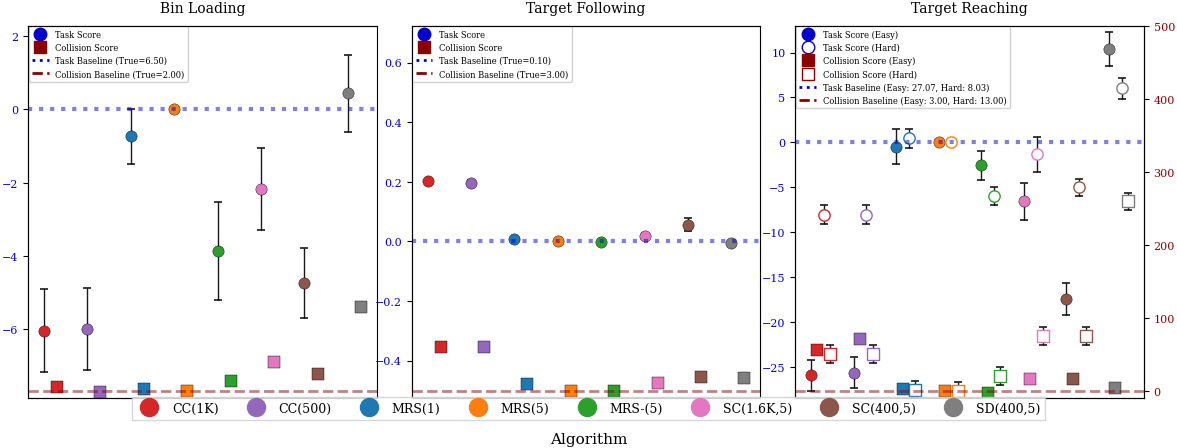

In [ ]:
def create_algorithm_tables(df):
    target_algorithms = ['O(400, 1)']# ['CC(1000)', 'SC(1600, 5)', 'O(400, 5)', 'SD(400, 5)', 'O(400, 1)']
    df_filtered = df[df['alg'].isin(target_algorithms)].copy()
    df_filtered['alg'] = df_filtered['alg'].replace('O(400, 5)', 'MRS(400, 5)')
    df_filtered['alg'] = df_filtered['alg'].replace('O(400, 1)', 'MRS(400, 1)')
    
    task_types = df_filtered['task_type'].unique()
    task_levels = sorted(df_filtered['task_level'].unique())
    
    for task_type in task_types:
        print(f"\n{'='*60}")
        print(f"TABLE FOR TASK TYPE: {task_type.upper()}")
        print(f"{'='*60}")
        
        task_data = df_filtered[df_filtered['task_type'] == task_type].copy()
        
        for metric in ['col-count-norm-mean', 'col-count-norm-std', 'task-norm-mean', 'task-norm-std']:
            print(f"\n--- {metric.upper()} ---")
            
            pivot_data = {}
            for alg in target_algorithms:
                if alg == 'O(400, 5)':
                    display_alg = 'MRS(400, 5)' 
                elif alg == 'O(400, 1)':
                    display_alg = 'MRS(400, 1)'
                else:
                    display_alg = alg
                
                pivot_data[display_alg] = {}
                
                for level in task_levels:
                    alg_level_data = task_data[
                        (task_data['alg'] == display_alg) & 
                        (task_data['task_level'] == level)
                    ]
                    
                    if not alg_level_data.empty:
                        if 'col-count' in metric:
                            # Use the correct column names: normalized_col_chance_mean/std
                            if 'mean' in metric:
                                value = alg_level_data['normalized_col_chance_mean'].iloc[0] * 500
                            else:
                                value = alg_level_data['normalized_col_chance_std'].iloc[0] * 500
                        else:
                            # Use the correct column names: normalized_task_val_mean/std
                            if 'mean' in metric:
                                value = alg_level_data['normalized_task_val_mean'].iloc[0]
                            else:
                                value = alg_level_data['normalized_task_val_std'].iloc[0]
                        pivot_data[display_alg][level] = f"{value:.3f}"
                    else:
                        pivot_data[display_alg][level] = "N/A"
            
            metric_df = pd.DataFrame(pivot_data).T
            metric_df.columns = [f"Level {col}" for col in metric_df.columns]
            print(metric_df.to_string())

# Run it
create_algorithm_tables(df_table)